# CLAM-TR V20 (UNI): Full-Scale 2x2 Factorial Experiment (Google Colab)
## 12 Experiments | 5-Fold CV | 9,128 Slides | UNI2-h + UNI

**Colab version** of `CLAM_TR_v20_FullScale_Local.ipynb`. Identical model code, training loop, and analysis.
Differences: paths point to Google Drive, setup uses apt-get/pip, extraction pipeline uses CLAM-compatible HSV tissue segmentation.

## 0. Environment Setup

In [1]:
# ── CLAM-TR V20: Full-Scale Experiment ──
# Colab version — runs on Google Drive

# Install system dependencies
import subprocess
for pkg in ['openslide-tools', 'libgl1-mesa-glx']:
    subprocess.run(['apt-get', 'install', '-y', '-q', pkg], capture_output=True)

# Install Python packages
for pkg in ['openslide-python', 'timm', 'huggingface_hub', 'h5py', 'opencv-python-headless']:
    subprocess.run(['pip', 'install', '-q', pkg], capture_output=True)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Setup complete.")

Mounted at /content/drive
Setup complete.


## 1. Imports

In [2]:
# ── Imports ──

import os
import json
import time
import h5py
import threading
import queue
import shutil
import concurrent.futures
from contextlib import nullcontext
import numpy as np
import pandas as pd
from datetime import datetime
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    cohen_kappa_score, accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score, classification_report
)
from sklearn.linear_model import LogisticRegression
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

import timm
from torchvision import transforms
from huggingface_hub import hf_hub_download, login as hf_login
from tqdm import tqdm
from PIL import Image

import cv2
import openslide

# ── HuggingFace Auth (needed for MahmoodLab/UNI gated model) ──
# Get your token from: https://huggingface.co/settings/tokens
# Also request access at: https://huggingface.co/MahmoodLab/UNI
HF_TOKEN = "hf_PLACEHOLDER_INSERT_YOUR_HF_TOKEN_HERE"  # <-- Replace with your actual token
hf_login(token=HF_TOKEN)
print("HuggingFace: Logged in")

# GPU check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

print("Setup complete.")

HuggingFace: Logged in
Device: cuda
GPU: Tesla T4
Memory: 15.6 GB
Setup complete.


## 2. Configuration

In [3]:
# ── Encoder Configurations ──
ENCODERS = {
    'UNI2-h': {
        'input_dim': 1536,
        'features_dir': '/content/drive/MyDrive/UNI_PANDA_Features',
        'file_ext': '.h5',
        'description': 'ViT-H/14 (DINOv2+SwiGLU), 1536-dim, 681M params, ~350K slides',
    },
    'UNI': {
        'input_dim': 1024,
        'features_dir': '/content/drive/MyDrive/UNI_features',
        'file_ext': '.pt',
        'description': 'ViT-L/16, 1024-dim, ~100K slides',
    },
}

# ── Which encoders to run ──
ACTIVE_ENCODERS = ['UNI']  # Both encoders

# AUTO_RUN = True: "Run All Cells" runs everything automatically
# AUTO_RUN = False: use individual Session cells manually
AUTO_RUN = True

# ── Paths ──
LABELS_PATH = '/content/drive/MyDrive/panda-data/prostate-cancer-grade-assessment/Kaggle-PANDA-1st-place-solution-master/input/train-5kfold_remove_noisy_by_0622_rad_13_08_ka_15_10.csv'
BASE_RESULTS_DIR = '/content/drive/MyDrive/CLAM_TR_Results/v20_fullscale'
os.makedirs(BASE_RESULTS_DIR, exist_ok=True)

# ============================================================
# DriveSyncer: background sync local checkpoints → Google Drive
# ============================================================
class DriveSyncer:
    """Background sync: local checkpoints -> Drive. Non-blocking.

    - Epoch checkpoints save to LOCAL SSD (instant, ~0.1s)
    - Every N epochs, background thread copies local -> Drive
    - At fold/experiment end, force sync ensures Drive is up-to-date
    - On new machine, set_encoder() restores Drive -> local automatically
    """

    def __init__(self, local_dir, drive_dir, sync_every_n_epochs=5):
        self.local_dir = local_dir
        self.drive_dir = drive_dir
        self.sync_every = sync_every_n_epochs
        os.makedirs(local_dir, exist_ok=True)
        os.makedirs(drive_dir, exist_ok=True)
        self._sync_thread = None

    def _do_sync(self):
        """Copy all checkpoint files from local -> Drive."""
        try:
            for fname in os.listdir(self.local_dir):
                src = os.path.join(self.local_dir, fname)
                dst = os.path.join(self.drive_dir, fname)
                if os.path.isfile(src):
                    shutil.copy2(src, dst)
        except Exception as e:
            print(f"    [Sync warning] {e}")

    def maybe_sync(self, epoch):
        """Sync every N epochs — non-blocking background thread."""
        if (epoch + 1) % self.sync_every == 0:
            if self._sync_thread and self._sync_thread.is_alive():
                self._sync_thread.join(timeout=30)
            self._sync_thread = threading.Thread(target=self._do_sync, daemon=True)
            self._sync_thread.start()

    def force_sync(self):
        """Blocking sync — call at fold/experiment completion."""
        if self._sync_thread and self._sync_thread.is_alive():
            self._sync_thread.join(timeout=60)
        self._do_sync()

# Global placeholder
drive_syncer = None


def set_encoder(encoder_name):
    """Set active encoder. Uses local SSD for checkpoints, syncs to Drive."""
    enc = ENCODERS[encoder_name]
    CONFIG['input_dim'] = enc['input_dim']
    CONFIG['encoder_name'] = encoder_name
    CONFIG['file_ext'] = enc['file_ext']

    global FEATURES_DIR, RESULTS_DIR, CHECKPOINT_DIR, DRIVE_CHECKPOINT_DIR, drive_syncer

    # Features: prefer local copy if available, else Drive (will preload to RAM anyway)
    _local_feat = f'/content/local_features/{encoder_name}'
    _local_n = len([f for f in os.listdir(_local_feat) if f.endswith(enc['file_ext'])]) if os.path.isdir(_local_feat) else 0
    FEATURES_DIR = _local_feat if _local_n >= 9000 else enc['features_dir']

    # Results dir on Drive (for final summaries, predictions)
    RESULTS_DIR = os.path.join(BASE_RESULTS_DIR, encoder_name)
    os.makedirs(RESULTS_DIR, exist_ok=True)

    # LOCAL checkpoint dir (fast SSD) — actual reads/writes during training
    CHECKPOINT_DIR = f'/content/local_checkpoints/{encoder_name}'
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

    # DRIVE checkpoint dir (persistent) — synced periodically
    DRIVE_CHECKPOINT_DIR = os.path.join(RESULTS_DIR, 'checkpoints')
    os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

    # ── On startup: restore from Drive -> Local (resume on new machine) ──
    local_files = set(os.listdir(CHECKPOINT_DIR)) if os.path.isdir(CHECKPOINT_DIR) else set()
    drive_files = set(os.listdir(DRIVE_CHECKPOINT_DIR)) if os.path.isdir(DRIVE_CHECKPOINT_DIR) else set()
    if drive_files and not local_files:
        print(f"  Restoring checkpoints from Drive -> local...")
        restored = 0
        for fname in drive_files:
            src = os.path.join(DRIVE_CHECKPOINT_DIR, fname)
            dst = os.path.join(CHECKPOINT_DIR, fname)
            if os.path.isfile(src):
                shutil.copy2(src, dst)
                restored += 1
        print(f"  Restored {restored} checkpoint files from Drive")

    # ── Migrate old root-level results (one-time fix) ──
    _root_ckpt = os.path.join(BASE_RESULTS_DIR, 'checkpoints')
    if os.path.isdir(_root_ckpt) and os.path.abspath(_root_ckpt) != os.path.abspath(DRIVE_CHECKPOINT_DIR):
        for _f in os.listdir(_root_ckpt):
            _src = os.path.join(_root_ckpt, _f)
            _dst = os.path.join(CHECKPOINT_DIR, _f)
            if os.path.isfile(_src) and not os.path.exists(_dst):
                shutil.copy2(_src, _dst)
                print(f'  Migrated checkpoint: {_f}')
        for _fname in ['best_lr.json', 'experiment_progress.json', 'fold_progress.json']:
            _src = os.path.join(BASE_RESULTS_DIR, _fname)
            _dst = os.path.join(RESULTS_DIR, _fname)
            if os.path.isfile(_src) and not os.path.exists(_dst):
                shutil.move(_src, _dst)
                print(f'  Migrated: {_fname}')
        _src_pred = os.path.join(BASE_RESULTS_DIR, 'predictions')
        _dst_pred = os.path.join(RESULTS_DIR, 'predictions')
        if os.path.isdir(_src_pred) and not os.path.isdir(_dst_pred):
            shutil.move(_src_pred, _dst_pred)
            print('  Migrated: predictions/')

    # Initialize DriveSyncer
    drive_syncer = DriveSyncer(CHECKPOINT_DIR, DRIVE_CHECKPOINT_DIR, sync_every_n_epochs=5)

    # Reset LR
    HP_SETS['default']['lr'] = 1e-4
    HP_SETS['best']['lr'] = 1e-4

    # Auto-load tuned LR
    for _lr_dir in [RESULTS_DIR, CHECKPOINT_DIR]:
        _lr_path = os.path.join(_lr_dir, 'best_lr.json')
        if os.path.exists(_lr_path):
            with open(_lr_path, 'r') as f:
                _lr_data = json.load(f)
            HP_SETS['default']['lr'] = _lr_data['best_lr']
            HP_SETS['best']['lr'] = _lr_data['best_lr']
            print(f"  Auto-loaded tuned LR: {_lr_data['best_lr']}")
            break

    # Recreate checkpoint manager for LOCAL directory
    global ckpt_manager
    try:
        ckpt_manager = CheckpointManager(CHECKPOINT_DIR)
        completed = ckpt_manager.get_all_results()
        if completed:
            print(f"  Resuming: {len(completed)} experiments already done")
    except NameError:
        pass

    print(f"Encoder set: {encoder_name} ({enc['input_dim']}d, {enc['file_ext']})")
    print(f"  Features: {FEATURES_DIR} (will preload to RAM)")
    print(f"  Local checkpoints: {CHECKPOINT_DIR}")
    print(f"  Drive checkpoints: {DRIVE_CHECKPOINT_DIR}")
    print(f"  Results: {RESULTS_DIR}")

# ── Model Config (V7 exact except input_dim) ──
CONFIG = {
    'input_dim': None,
    'encoder_name': None,
    'file_ext': None,
    'hidden_dim': 512,
    'n_classes': 6,
    'num_heads': 8,
    'K': 128,
    'ffn_expansion': 4,
    'num_groups': 8,
    'epochs': 50,
    'patience': 10,
    'early_stop_threshold': 0.001,
    'max_grad_norm': 1.0,
    'n_folds': 5,
    'seed': 42,
    'use_class_weights': True,
}

# ── HP Sets (V7 exact) ──
HP_SETS = {
    'default': {
        'attention_temperature': 1.0,
        'dropout': 0.25,
        'optimizer': 'adam',
        'lr': 1e-4,
        'weight_decay': 1e-5,
        'loss': 'ce',
        'label_smoothing': 0.1,
        'focal_gamma': None,
        'gamma_values': [0.80, 0.85, 0.90, 0.93, 0.95, 0.97, 0.98, 0.99],
    },
    'best': {
        'attention_temperature': 0.7,
        'dropout': 0.15,
        'optimizer': 'adamw',
        'lr': 1e-4,
        'weight_decay': 1e-5,
        'loss': 'focal',
        'label_smoothing': 0.1,
        'focal_gamma': 1.0,
        'gamma_values': [0.88, 0.90, 0.92, 0.94, 0.96, 0.98, 0.99, 0.995],
    },
}

# ── V7 Reference Values ──
V7_REFERENCE = {
    'default': {
        'ABMIL': 0.8482, 'RetNet': 0.8685,
        'SpatialMult': 0.8688, 'SpatialMultRetNet': 0.8686,
    },
    'best': {
        'ABMIL': 0.8482,
        'RetNet': 0.8761, 'SpatialMult': 0.8654,
        'SpatialMultRetNet': 0.8714,
    },
    'interaction': {
        'default': -0.0001,
        'best': -0.0218,
    },
}

# ── Experiment Registry ──
EXPERIMENTS = [
    ('ABMIL_defaultHP',             'default'),
    ('ABMIL_bestHP',                'best'),
    ('DualBranch_defaultHP',        'default'),
    ('DualBranch_bestHP',           'best'),
    ('RetNet_defaultHP',            'default'),
    ('RetNet_bestHP',               'best'),
    ('SpatialMult_defaultHP',       'default'),
    ('SpatialMult_bestHP',          'best'),
    ('SpatialMultRetNet_defaultHP', 'default'),
    ('SpatialMultRetNet_bestHP',    'best'),
    ('SpatialAdd_defaultHP',        'default'),
    ('SpatialAdd_bestHP',           'best'),
]

# Initialize with first active encoder
set_encoder(ACTIVE_ENCODERS[0])

print(f"\nConfig: {CONFIG['input_dim']}d input, {CONFIG['hidden_dim']}d hidden, "
      f"{CONFIG['n_classes']} classes, {CONFIG['num_heads']} heads, K={CONFIG['K']}")
print(f"Active encoders: {ACTIVE_ENCODERS}")
print(f"Experiments: {len(EXPERIMENTS)} total ({len(EXPERIMENTS)} x {CONFIG['n_folds']} folds = "
      f"{len(EXPERIMENTS) * CONFIG['n_folds']} training runs per encoder)")


  Restoring checkpoints from Drive -> local...
  Restored 128 checkpoint files from Drive
  Auto-loaded tuned LR: 0.0002
Encoder set: UNI (1024d, .pt)
  Features: /content/drive/MyDrive/UNI_features (will preload to RAM)
  Local checkpoints: /content/local_checkpoints/UNI
  Drive checkpoints: /content/drive/MyDrive/CLAM_TR_Results/v20_fullscale/UNI/checkpoints
  Results: /content/drive/MyDrive/CLAM_TR_Results/v20_fullscale/UNI

Config: 1024d input, 512d hidden, 6 classes, 8 heads, K=128
Active encoders: ['UNI']
Experiments: 12 total (12 x 5 folds = 60 training runs per encoder)


## 2.1 Feature Encoder Validation

In [4]:
def validate_encoder_features(encoder_name, sample_n=20):
    """Validate features for a given encoder. Run before training."""
    enc = ENCODERS[encoder_name]
    feat_dir = FEATURES_DIR
    expected_dim = enc['input_dim']
    file_ext = enc['file_ext']

    print("=" * 60)
    print(f"FEATURE VALIDATION: {encoder_name}")
    print(f"  Expected dim: {expected_dim}, format: {file_ext}")
    print(f"  Directory: {feat_dir}")
    print("=" * 60)

    # Check 1: Directory exists
    if not os.path.isdir(feat_dir):
        print(f"  FAIL: Directory not found: {feat_dir}")
        return False

    # Check 2: Count files
    all_files = [f for f in os.listdir(feat_dir) if f.endswith(file_ext)]
    print(f"\n  [1/6] Found {len(all_files)} {file_ext} files")
    if len(all_files) == 0:
        print(f"  FAIL: No {file_ext} files in {feat_dir}")
        return False

    # Check 3: Load samples and verify shape/dim
    import random
    random.seed(42)
    samples = random.sample(all_files, min(sample_n, len(all_files)))

    dims_ok, shapes, stats_list = 0, [], []
    has_nan, has_inf = False, False

    print(f"\n  [2/6] Checking {len(samples)} sample files:")
    for fname in samples:
        fpath = os.path.join(feat_dir, fname)
        try:
            if file_ext == '.h5':
                with h5py.File(fpath, 'r') as f:
                    keys = list(f.keys())
                    feat = f['features'][:]
                    has_coords = 'coords' in keys
                    if has_coords:
                        coords = f['coords'][:]
                # h5 format: [1, N, D] -> squeeze to [N, D]
                if feat.ndim == 3:
                    feat = feat.squeeze(0)
            elif file_ext == '.pt':
                data = torch.load(fpath, map_location='cpu', weights_only=False)
                if isinstance(data, dict):
                    feat = data.get('features', data.get('embeddings', None))
                    if feat is None:
                        feat = list(data.values())[0]
                    has_coords = 'coords' in data
                elif isinstance(data, torch.Tensor):
                    feat = data
                    has_coords = False
                feat = feat.numpy() if isinstance(feat, torch.Tensor) else feat
                if feat.ndim == 3:
                    feat = feat.squeeze(0)

            n_patches, actual_dim = feat.shape
            shapes.append(n_patches)

            if actual_dim == expected_dim:
                dims_ok += 1
            else:
                print(f"    MISMATCH {fname}: dim={actual_dim}, expected={expected_dim}")

            # NaN/Inf check
            import numpy as np
            if np.isnan(feat).any():
                has_nan = True
                print(f"    WARNING: NaN in {fname}")
            if np.isinf(feat).any():
                has_inf = True
                print(f"    WARNING: Inf in {fname}")

            # Stats
            stats_list.append({
                'mean': float(np.mean(feat)),
                'std': float(np.std(feat)),
                'min': float(np.min(feat)),
                'max': float(np.max(feat)),
            })

        except Exception as e:
            print(f"    ERROR loading {fname}: {e}")

    print(f"\n  [3/6] Dimension check: {dims_ok}/{len(samples)} correct ({expected_dim}d)")

    # Check 4: Patch count stats
    if shapes:
        shapes_arr = np.array(shapes)
        print(f"\n  [4/6] Patch counts: min={shapes_arr.min()}, "
              f"median={np.median(shapes_arr):.0f}, max={shapes_arr.max()}")

    # Check 5: Feature statistics (encoder fingerprint)
    if stats_list:
        means = [s['mean'] for s in stats_list]
        stds = [s['std'] for s in stats_list]
        print(f"\n  [5/6] Feature statistics (encoder fingerprint):")
        print(f"    Mean of means: {np.mean(means):.4f} (std: {np.std(means):.4f})")
        print(f"    Mean of stds:  {np.mean(stds):.4f} (std: {np.std(stds):.4f})")

        # Sanity: features should not be all zeros or constant
        if np.mean(stds) < 0.01:
            print(f"    WARNING: Very low std - features may be degenerate!")
        if abs(np.mean(means)) > 10:
            print(f"    WARNING: Large mean magnitude - check normalization")

    # Check 6: Summary
    print(f"\n  [6/6] Summary:")
    ok = dims_ok == len(samples) and not has_nan and not has_inf and len(all_files) > 0
    if ok:
        print(f"    PASSED: {encoder_name} features look valid")
        print(f"    {len(all_files)} files, {expected_dim}d, no NaN/Inf")
    else:
        issues = []
        if dims_ok < len(samples):
            issues.append(f"dim mismatch ({dims_ok}/{len(samples)})")
        if has_nan:
            issues.append("NaN detected")
        if has_inf:
            issues.append("Inf detected")
        print(f"    ISSUES: {', '.join(issues)}")

    return ok


# Auto-detect available encoders
print("Checking available encoders:\n")
available_encoders = []
for enc_name in ACTIVE_ENCODERS:
    enc = ENCODERS[enc_name]
    if os.path.isdir(enc['features_dir']):
        available_encoders.append(enc_name)
        print(f"  {enc_name}: FOUND at {enc['features_dir']}")
    else:
        print(f"  {enc_name}: NOT FOUND at {enc['features_dir']}")

if not available_encoders:
    print("\nERROR: No active encoder features found! Check ENCODERS paths.")
else:
    print(f"\nAvailable: {available_encoders}")
    # Validate the first available encoder
    validate_encoder_features(available_encoders[0])

Checking available encoders:

  UNI: FOUND at /content/drive/MyDrive/UNI_features

Available: ['UNI']
FEATURE VALIDATION: UNI
  Expected dim: 1024, format: .pt
  Directory: /content/drive/MyDrive/UNI_features

  [1/6] Found 9128 .pt files

  [2/6] Checking 20 sample files:

  [3/6] Dimension check: 20/20 correct (1024d)

  [4/6] Patch counts: min=204, median=434, max=884

  [5/6] Feature statistics (encoder fingerprint):
    Mean of means: -0.0120 (std: 0.0057)
    Mean of stds:  1.2042 (std: 0.0123)

  [6/6] Summary:
    PASSED: UNI features look valid
    9128 files, 1024d, no NaN/Inf


## 2.2 UNI v1 Feature Extraction (from Raw PANDA Slides)

**Skip this section if using UNI2-h only** (pre-extracted features).

This section extracts 1024-dim UNI v1 features from the 9,128 raw PANDA `.tiff` slides.
Pipeline: `WSI -> HSV tissue seg -> 256x256 patches at 20x -> mag normalize -> white/black filter -> Resize(224) -> ImageNet norm -> UNI ViT-L/16 -> 1024-dim .pt files`

**CLAM-compatible preprocessing:**
- HSV saturation tissue segmentation (sat>8, blur=7, close=4)
- Magnification normalization: 40x slides read 512x512, resized to 256x256
- White patch filter (mean sat < 5) + Black patch filter (mean RGB < 40)
- Multi-worker pipeline: N CPU workers + 1 GPU thread

**Checkpointing:** Progress saved to Drive every 50 slides. Safe to restart.

In [5]:
# ── Feature Extraction Configuration ──

SLIDES_DIR = '/content/drive/MyDrive/PANDA_Subset_9128/images/'
PREPROCESSING_DIR = '/content/drive/MyDrive/CLAM_TR_Preprocessing/v20/'

EXTRACTION_CONFIG = {
    'slides_dir': SLIDES_DIR,
    'slide_ext': '.tiff',
    'output_dir': ENCODERS['UNI']['features_dir'],
    'progress_dir': os.path.join(PREPROCESSING_DIR, 'progress'),
    'patch_size': 256,
    'target_magnification': 20,
    'encoder_batch_size': 256,
    'checkpoint_every': 50,
    'min_tissue_ratio': 0.5,
    'sat_thresh': 8,             # HSV saturation threshold (CLAM default)
    'median_blur': 7,            # Median blur kernel (CLAM default)
    'morph_close': 4,            # Morphological closing kernel (CLAM default)
    'white_sat_thresh': 5,       # White patch filter (CLAM isWhitePatch)
    'black_rgb_thresh': 40,      # Black patch filter (CLAM isBlackPatch)
    'min_patches_per_slide': 10,
    'n_workers': 5,              # CPU workers for multi-worker pipeline
    'retry_failed': True,
    'local_temp_dir': '/content/local_slides_temp',
}

# Create directories
os.makedirs(EXTRACTION_CONFIG['output_dir'], exist_ok=True)
os.makedirs(EXTRACTION_CONFIG['progress_dir'], exist_ok=True)

print("Feature extraction config:")
for k, v in EXTRACTION_CONFIG.items():
    print(f"  {k}: {v}")

# Check if raw slides exist
if os.path.isdir(EXTRACTION_CONFIG['slides_dir']):
    slide_files = [f for f in os.listdir(EXTRACTION_CONFIG['slides_dir'])
                   if f.endswith(EXTRACTION_CONFIG['slide_ext'])]
    print(f"\nFound {len(slide_files)} slides in {EXTRACTION_CONFIG['slides_dir']}")

    existing = len([f for f in os.listdir(EXTRACTION_CONFIG['output_dir'])
                    if f.endswith('.pt')]) if os.path.isdir(EXTRACTION_CONFIG['output_dir']) else 0
    print(f"Existing features: {existing}")
    print(f"Remaining: ~{len(slide_files) - existing}")
else:
    print(f"\nWARNING: Slides not found at {EXTRACTION_CONFIG['slides_dir']}")
    print("Update SLIDES_DIR above!")

Feature extraction config:
  slides_dir: /content/drive/MyDrive/PANDA_Subset_9128/images/
  slide_ext: .tiff
  output_dir: /content/drive/MyDrive/UNI_features
  progress_dir: /content/drive/MyDrive/CLAM_TR_Preprocessing/v20/progress
  patch_size: 256
  target_magnification: 20
  encoder_batch_size: 256
  checkpoint_every: 50
  min_tissue_ratio: 0.5
  sat_thresh: 8
  median_blur: 7
  morph_close: 4
  white_sat_thresh: 5
  black_rgb_thresh: 40
  min_patches_per_slide: 10
  n_workers: 5
  retry_failed: True
  local_temp_dir: /content/local_slides_temp

Found 9128 slides in /content/drive/MyDrive/PANDA_Subset_9128/images/
Existing features: 9128
Remaining: ~0


In [6]:
# ══════════════════════════════════════════════════════════════════
# Slide Preprocessor — CLAM-compatible tissue detection + magnification normalization
# ══════════════════════════════════════════════════════════════════

class SlidePreprocessor:
    """Extract tissue patches from WSI with magnification normalization and CLAM-style tissue detection.

    Correctness features vs naive approach:
    1. HSV saturation-based tissue segmentation (not Otsu on grayscale)
    2. Magnification normalization: 40x patches resized to match 20x physical area
    3. White patch filtering by HSV saturation (CLAM isWhitePatch)
    4. Black patch filtering by RGB threshold (CLAM isBlackPatch)
    """

    def __init__(self, patch_size=256, target_mag=20, min_tissue_ratio=0.5,
                 sat_thresh=8, median_blur=7, morph_close=4,
                 white_sat_thresh=5, black_rgb_thresh=40):
        self.patch_size = patch_size
        self.target_mag = target_mag
        self.min_tissue_ratio = min_tissue_ratio
        self.sat_thresh = sat_thresh
        self.median_blur = median_blur
        self.morph_close = morph_close
        self.white_sat_thresh = white_sat_thresh
        self.black_rgb_thresh = black_rgb_thresh

    def get_extraction_params(self, slide):
        """Find best pyramid level and calculate read/step sizes for target magnification.

        For 40x slides without a native 20x level:
          reads 512x512 at 40x level 0 and resizes to 256x256,
          ensuring patches cover the same physical tissue area as 256x256 at 20x.
        For 20x slides: reads 256x256 directly (no resize needed).

        Returns: (level, read_size, step_l0, actual_mag, obj_power)
        """
        try:
            obj_power = float(slide.properties.get('openslide.objective-power', 20))
        except (ValueError, KeyError):
            obj_power = 20

        downsample_needed = obj_power / self.target_mag
        best_level, best_diff = 0, float('inf')
        for level in range(slide.level_count):
            diff = abs(slide.level_downsamples[level] - downsample_needed)
            if diff < best_diff:
                best_diff, best_level = diff, level

        level_ds = slide.level_downsamples[best_level]
        actual_mag = obj_power / level_ds
        mag_ratio = actual_mag / self.target_mag  # >1 means higher mag than target

        # Read larger region if mag is higher, then resize to patch_size
        read_size = int(round(self.patch_size * mag_ratio))
        # Step in level 0 coordinates (non-overlapping physical coverage)
        step_l0 = int(round(read_size * level_ds))

        return best_level, read_size, step_l0, actual_mag, obj_power

    def segment_tissue(self, slide):
        """HSV saturation-based tissue segmentation (matches CLAM pipeline).

        Steps: RGB -> HSV -> Saturation channel -> Median blur -> Binary threshold -> Morphological closing
        CLAM defaults: sat_thresh=8, median_blur=7, morph_close=4
        """
        # Auto-select low-resolution level for segmentation (~64x downsample)
        seg_level = 0
        for level in range(slide.level_count):
            if slide.level_downsamples[level] <= 64:
                seg_level = level

        dims = slide.level_dimensions[seg_level]
        img = np.array(slide.read_region((0, 0), seg_level, dims).convert('RGB'))

        # HSV -> Saturation -> Median blur -> Binary threshold
        img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        img_med = cv2.medianBlur(img_hsv[:, :, 1], self.median_blur)
        _, tissue_mask = cv2.threshold(img_med, self.sat_thresh, 255, cv2.THRESH_BINARY)

        # Morphological closing to fill small gaps in tissue
        if self.morph_close > 0:
            kernel = np.ones((self.morph_close, self.morph_close), np.uint8)
            tissue_mask = cv2.morphologyEx(tissue_mask, cv2.MORPH_CLOSE, kernel)

        return tissue_mask, seg_level

    def extract_patches_and_coords(self, slide):
        """Extract tissue patches at target magnification with proper normalization.

        Key behavior:
        - 20x slides: reads 256x256 patches directly
        - 40x slides (no 20x level): reads 512x512, resizes to 256x256
          -> same physical area coverage, consistent feature representations
        - Filters: HSV tissue mask + white patch (sat<5) + black patch (rgb<40)
        """
        level, read_size, step_l0, actual_mag, obj_power = self.get_extraction_params(slide)
        tissue_mask, seg_level = self.segment_tissue(slide)
        seg_ds = slide.level_downsamples[seg_level]
        mask_h, mask_w = tissue_mask.shape
        needs_resize = (read_size != self.patch_size)

        patches, coords = [], []
        w0, h0 = slide.level_dimensions[0]

        for y in range(0, h0 - step_l0 + 1, step_l0):
            for x in range(0, w0 - step_l0 + 1, step_l0):
                # Check tissue ratio on segmentation mask
                mx = min(int(x / seg_ds), mask_w - 1)
                my = min(int(y / seg_ds), mask_h - 1)
                mw = max(1, min(int(step_l0 / seg_ds), mask_w - mx))
                mh = max(1, min(int(step_l0 / seg_ds), mask_h - my))
                if mw <= 0 or mh <= 0:
                    continue

                tissue_ratio = np.mean(tissue_mask[my:my+mh, mx:mx+mw] > 0)
                if tissue_ratio < self.min_tissue_ratio:
                    continue

                try:
                    patch_pil = slide.read_region((x, y), level,
                                                  (read_size, read_size)).convert('RGB')
                    patch_arr = np.array(patch_pil)

                    # White patch check: low saturation = background (CLAM isWhitePatch)
                    patch_hsv = cv2.cvtColor(patch_arr, cv2.COLOR_RGB2HSV)
                    if np.mean(patch_hsv[:, :, 1]) < self.white_sat_thresh:
                        continue

                    # Black patch check: all channels dark = artifact (CLAM isBlackPatch)
                    if np.all(np.mean(patch_arr, axis=(0, 1)) < self.black_rgb_thresh):
                        continue

                    # Magnification normalization: resize if higher mag than target
                    if needs_resize:
                        patch_pil = patch_pil.resize((self.patch_size, self.patch_size),
                                                     Image.LANCZOS)
                        patch_arr = np.array(patch_pil)

                    patches.append(patch_arr)
                    coords.append([x, y])
                except Exception:
                    continue

        return patches, np.array(coords, dtype=np.int32) if coords else np.zeros((0, 2), dtype=np.int32)


# ══════════════════════════════════════════════════════════════════
# UNI v1 Encoder
# ══════════════════════════════════════════════════════════════════

class UNIv1Encoder(nn.Module):
    """UNI v1 (ViT-L/16, 1024-dim) from MahmoodLab."""

    def __init__(self):
        super().__init__()
        print("Loading UNI v1 (ViT-L/16)...")
        self.encoder = timm.create_model(
            "vit_large_patch16_224",
            img_size=224, patch_size=16,
            init_values=1e-5,
            num_classes=0,
            dynamic_img_size=True
        )
        weights_path = hf_hub_download("MahmoodLab/UNI", "pytorch_model.bin")
        self.encoder.load_state_dict(
            torch.load(weights_path, map_location="cpu", weights_only=False), strict=True)
        for p in self.encoder.parameters():
            p.requires_grad = False
        print(f"UNI v1 loaded: {sum(p.numel() for p in self.parameters()):,} params (frozen)")

    def forward(self, x):
        return self.encoder(x)


# ══════════════════════════════════════════════════════════════════
# Slide Reading Verification
# ══════════════════════════════════════════════════════════════════

def verify_slide_reading(slides_dir, slide_ext, n_samples=5):
    """Verify OpenSlide reads slides correctly before full extraction."""
    print("=" * 60)
    print("SLIDE READING VERIFICATION")
    print("=" * 60)

    slide_files = sorted([f for f in os.listdir(slides_dir) if f.endswith(slide_ext)])
    if not slide_files:
        print(f"  ERROR: No {slide_ext} files in {slides_dir}")
        return False

    import random
    random.seed(42)
    samples = random.sample(slide_files, min(n_samples, len(slide_files)))
    issues = []
    test_preprocessor = SlidePreprocessor()

    for fname in samples:
        fpath = os.path.join(slides_dir, fname)
        slide = openslide.OpenSlide(fpath)
        level, read_size, step_l0, actual_mag, obj_power = test_preprocessor.get_extraction_params(slide)
        level_dims = slide.level_dimensions[level]
        needs_resize = (read_size != 256)

        # Higher mag is fine (patches get resized to correct physical area)
        # Only flag if effective mag is LOWER than target
        if actual_mag >= 19.0:
            status = "OK"
        elif actual_mag >= 10.0:
            status = "WARNING"
            issues.append(f"{fname}: low mag {actual_mag:.1f}x (target 20x)")
        else:
            status = "FAIL"
            issues.append(f"{fname}: very low mag {actual_mag:.1f}x")

        resize_note = f" -> resize {read_size}->256" if needs_resize else ""
        print(f"  {fname}: obj={obj_power}x, level={level} "
              f"({level_dims[0]}x{level_dims[1]}), eff={actual_mag:.1f}x, "
              f"read={read_size}x{read_size}{resize_note} [{status}]")

        try:
            test_patch = slide.read_region((0, 0), level, (read_size, read_size)).convert('RGB')
            arr = np.array(test_patch)
            hsv = cv2.cvtColor(arr, cv2.COLOR_RGB2HSV)
            print(f"    Patch: {arr.shape}, mean_rgb={arr.mean():.1f}, mean_sat={hsv[:,:,1].mean():.1f}")
        except Exception as e:
            print(f"    Test patch FAILED: {e}")
            issues.append(f"{fname}: read_region failed")

        slide.close()

    if issues:
        print(f"\n  ISSUES: {len(issues)}")
        for i in issues:
            print(f"    - {i}")
        return False
    print(f"\n  All {len(samples)} slides OK")
    return True


# ══════════════════════════════════════════════════════════════════
# Multi-Worker Feature Extraction Pipeline
# ══════════════════════════════════════════════════════════════════

def extract_uni_features():
    """Extract UNI v1 features with multi-worker pipeline.

    N CPU workers (copy + patch + transform) feed a GPU queue.
    1 GPU worker (main thread) runs UNI inference and saves .pt files.
    Local slides are deleted after extraction to save disk space.
    """
    cfg = EXTRACTION_CONFIG
    N_WORKERS = cfg['n_workers']
    LOCAL_TEMP = cfg['local_temp_dir']

    # Progress tracking (on Drive for crash persistence)
    progress_path = os.path.join(cfg['progress_dir'], 'uni_extraction_progress.json')
    if os.path.exists(progress_path):
        with open(progress_path, 'r') as f:
            progress = json.load(f)
        completed = set(progress.get('completed', []))
        failed_prev = set(progress.get('failed', []))
    else:
        completed, failed_prev = set(), set()

    # Get all slide IDs
    slide_files = sorted([f for f in os.listdir(cfg['slides_dir'])
                          if f.endswith(cfg['slide_ext'])])
    all_ids = [f.replace(cfg['slide_ext'], '') for f in slide_files]

    # Check existing .pt features
    existing_pts = set()
    if os.path.isdir(cfg['output_dir']):
        existing_pts = {f.replace('.pt', '') for f in os.listdir(cfg['output_dir'])
                        if f.endswith('.pt')}
    completed = completed | existing_pts

    retry_failed = cfg.get('retry_failed', True)
    if retry_failed:
        to_process = [sid for sid in all_ids if sid not in completed]
    else:
        to_process = [sid for sid in all_ids if sid not in completed and sid not in failed_prev]

    print("=" * 60)
    print("UNI v1 FEATURE EXTRACTION (Multi-Worker Pipeline)")
    print("=" * 60)
    print(f"Total slides:      {len(all_ids)}")
    print(f"Already done:      {len(completed)}")
    print(f"Previously failed: {len(failed_prev)}")
    print(f"To process:        {len(to_process)}")
    print(f"Output dir:        {cfg['output_dir']}")
    print(f"CPU workers:       {N_WORKERS}")
    print(f"Tissue seg:        HSV saturation (sat>{cfg.get('sat_thresh',8)}, blur={cfg.get('median_blur',7)})")
    print(f"Patch filtering:   white(sat<{cfg.get('white_sat_thresh',5)}) + black(rgb<{cfg.get('black_rgb_thresh',40)})")
    print(f"Magnification:     target {cfg['target_magnification']}x (40x slides auto-resized)")

    if not to_process:
        print("\nAll slides already processed!")
        return

    # Verify slides first
    print()
    if not verify_slide_reading(cfg['slides_dir'], cfg['slide_ext']):
        resp = input("Issues detected. Continue? (y/n): ").strip().lower()
        if resp != 'y':
            return
    print()

    # Load UNI model (ONE model, shared across threads for inference)
    encoder = UNIv1Encoder().to(device).eval()

    # ImageNet normalization constants (GPU batch transform replaces CPU img_transform)
    _gpu_mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
    _gpu_std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

    preprocessor = SlidePreprocessor(
        patch_size=cfg['patch_size'],
        target_mag=cfg['target_magnification'],
        min_tissue_ratio=cfg['min_tissue_ratio'],
        sat_thresh=cfg.get('sat_thresh', 8),
        median_blur=cfg.get('median_blur', 7),
        morph_close=cfg.get('morph_close', 4),
        white_sat_thresh=cfg.get('white_sat_thresh', 5),
        black_rgb_thresh=cfg.get('black_rgb_thresh', 40),
    )

    # ── Queues ──
    os.makedirs(LOCAL_TEMP, exist_ok=True)
    slide_ids_q = queue.Queue()
    for sid in to_process:
        slide_ids_q.put(sid)

    gpu_q = queue.Queue(maxsize=N_WORKERS)
    preprocess_errors = []
    _lock = threading.Lock()

    def _cpu_worker():
        """Read slide (Drive direct or local fallback), extract patches as raw numpy."""
        while True:
            try:
                slide_id = slide_ids_q.get_nowait()
            except Exception:
                return

            src_path = os.path.join(cfg['slides_dir'], f"{slide_id}{cfg['slide_ext']}")
            local_path = os.path.join(LOCAL_TEMP, f"{slide_id}{cfg['slide_ext']}")
            used_local = False

            try:
                # Try reading directly from Drive (skip copy = ~15 sec saved per slide)
                try:
                    slide = openslide.OpenSlide(src_path)
                except Exception:
                    # Fallback: copy to local then open
                    shutil.copy2(src_path, local_path)
                    used_local = True
                    slide = openslide.OpenSlide(local_path)

                patches, coords = preprocessor.extract_patches_and_coords(slide)
                slide.close()

                if len(patches) < cfg['min_patches_per_slide']:
                    with _lock:
                        preprocess_errors.append((slide_id, f"only {len(patches)} patches"))
                    gpu_q.put((slide_id, None, None, local_path if used_local else None))
                    continue

                patch_tensors = torch.from_numpy(np.stack(patches))  # (N, 256, 256, 3) uint8
                coords_tensor = torch.tensor(coords, dtype=torch.float32)
                del patches

                gpu_q.put((slide_id, patch_tensors, coords_tensor, local_path if used_local else None))

            except Exception as e:
                with _lock:
                    preprocess_errors.append((slide_id, str(e)))
                gpu_q.put((slide_id, None, None, local_path if used_local and os.path.exists(local_path) else None))

    # ── Start CPU workers ──
    actual_workers = min(N_WORKERS, len(to_process))
    cpu_threads = []
    for _ in range(actual_workers):
        t = threading.Thread(target=_cpu_worker, daemon=True)
        t.start()
        cpu_threads.append(t)
    print(f"  {actual_workers} CPU workers started")

    # ── GPU loop (main thread) ──
    completed_list = list(completed)
    failed_list = list(failed_prev)
    batch_size = cfg['encoder_batch_size']
    start_time = time.time()
    session_count = 0
    processed_count = 0
    total = len(to_process)

    pbar = tqdm(total=total, desc="Extracting", unit="slide")

    while processed_count < total:
        try:
            item = gpu_q.get(timeout=300)
        except Exception:
            alive = sum(1 for t in cpu_threads if t.is_alive())
            print(f"\n  Queue timeout. {alive}/{actual_workers} workers alive")
            if alive == 0:
                break
            continue

        slide_id, patch_tensors, coords_tensor, local_path = item
        processed_count += 1

        if patch_tensors is None:
            failed_list.append(slide_id)
            pbar.update(1)
            try:
                if local_path and os.path.exists(local_path):
                    os.remove(local_path)
            except Exception:
                pass
            continue

        try:
            # GPU transform + inference (fp16 autocast, fp32 output)
            all_features = []
            with torch.inference_mode(), torch.amp.autocast('cuda'):
                for b in range(0, len(patch_tensors), batch_size):
                    batch_raw = patch_tensors[b:b+batch_size]  # (B, 256, 256, 3) uint8
                    batch_gpu = batch_raw.to(device).permute(0, 3, 1, 2).float() / 255.0  # (B, 3, 256, 256)
                    batch_gpu = torch.nn.functional.interpolate(batch_gpu, size=(224, 224), mode='bilinear', align_corners=False)
                    batch_gpu = (batch_gpu - _gpu_mean) / _gpu_std
                    feats = encoder(batch_gpu).float().cpu()  # .float() ensures fp32 output
                    all_features.append(feats)
                    del batch_raw, batch_gpu

            features_cat = torch.cat(all_features, dim=0)

            # Save .pt (format: {'features': [N, 1024], 'coords': [N, 2]})
            output_path = os.path.join(cfg['output_dir'], f"{slide_id}.pt")
            torch.save({'features': features_cat, 'coords': coords_tensor}, output_path)

            completed_list.append(slide_id)
            session_count += 1
            del patch_tensors, all_features, features_cat, coords_tensor

            elapsed = time.time() - start_time
            rate = session_count / (elapsed / 60)
            remaining = (total - processed_count) / max(rate, 0.01)
            pbar.set_postfix(rate=f"{rate:.1f}/min", eta=f"{remaining:.0f}min")

        except Exception as e:
            print(f"\n  GPU ERROR {slide_id}: {e}")
            failed_list.append(slide_id)

        finally:
            try:
                if local_path and os.path.exists(local_path):
                    os.remove(local_path)
            except Exception:
                pass

        pbar.update(1)

        # Checkpoint
        if session_count % cfg['checkpoint_every'] == 0 and session_count > 0:
            with open(progress_path, 'w') as f:
                json.dump({
                    'completed': completed_list,
                    'failed': failed_list,
                    'total': len(all_ids),
                    'timestamp': datetime.now().isoformat()
                }, f)
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    pbar.close()

    for t in cpu_threads:
        t.join(timeout=10)

    # Final save
    with open(progress_path, 'w') as f:
        json.dump({
            'completed': completed_list,
            'failed': failed_list,
            'total': len(all_ids),
            'timestamp': datetime.now().isoformat()
        }, f)

    elapsed = time.time() - start_time
    print(f"\n{'=' * 60}")
    print(f"EXTRACTION COMPLETE")
    print(f"  This session: {session_count} slides in {elapsed/60:.1f} min")
    print(f"  Total: {len(completed_list)}/{len(all_ids)} done, {len(failed_list)} failed")
    if preprocess_errors:
        print(f"  Preprocess errors: {len(preprocess_errors)}")
        for sid, err in preprocess_errors[:5]:
            print(f"    - {sid}: {err}")
    print(f"  Output: {cfg['output_dir']}")
    print(f"{'=' * 60}")

    # Cleanup
    shutil.rmtree(LOCAL_TEMP, ignore_errors=True)
    del encoder
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Pipeline ready.")
print("  SlidePreprocessor: HSV tissue seg + mag normalization + 256x256 patches")
print("  UNIv1Encoder: ViT-L/16, 1024-dim (MahmoodLab/UNI)")
print("  extract_uni_features(): multi-worker CPU + 1 GPU pipeline")

Pipeline ready.
  SlidePreprocessor: HSV tissue seg + mag normalization + 256x256 patches
  UNIv1Encoder: ViT-L/16, 1024-dim (MahmoodLab/UNI)
  extract_uni_features(): multi-worker CPU + 1 GPU pipeline


In [7]:
# ── Validate OpenSlide + Slide Reading (run before extraction) ──
# Skipped in AUTO_RUN mode (run_all_encoders validates before extraction)
if not AUTO_RUN:
    print("OpenSlide check:")
    print(f"  OK: OpenSlide {openslide.__library_version__}")
    print()
    verify_slide_reading(
        slides_dir=EXTRACTION_CONFIG["slides_dir"],
        slide_ext=EXTRACTION_CONFIG["slide_ext"],
        n_samples=5
    )
else:
    print("OpenSlide validation deferred to run_all_encoders()")

OpenSlide validation deferred to run_all_encoders()


In [8]:
# ── Run UNI v1 Feature Extraction ──
# Skipped in AUTO_RUN mode (run_all_encoders handles extraction automatically)
if not AUTO_RUN and 'UNI' in ACTIVE_ENCODERS:
    uni_dir = ENCODERS['UNI']['features_dir']
    existing = len([f for f in os.listdir(uni_dir) if f.endswith('.pt')]) if os.path.isdir(uni_dir) else 0
    print(f"Existing UNI v1 features: {existing}")

    if existing < 9000:
        print("Starting UNI v1 feature extraction...")
        extract_uni_features()
    else:
        print(f"UNI v1 features already extracted ({existing} files). Skipping.")
else:
    if AUTO_RUN:
        print("UNI v1 extraction deferred to run_all_encoders()")
    else:
        print("UNI not in ACTIVE_ENCODERS. Skipping feature extraction.")

UNI v1 extraction deferred to run_all_encoders()


## 2.3 Copy Features to Local Disk


In [9]:
# ── SKIP local file copy — features will be preloaded into RAM ──
# Google Drive FUSE is too slow for 9128 individual file copies (~28s/file = 72+ hours).
# Instead, we use parallel threaded loading directly into RAM (51GB available).
# This takes ~12-15 min vs 72+ hours for file-by-file copy.
#
# For UNI (1024d): features then get packed onto GPU in float16 (~8.8GB)
# For UNI2-h (1536d): may stay in CPU RAM if GPU is too small (auto-detected)

print("Skipping local file copy — features will be preloaded into RAM after Phase 0.")
print(f"Feature source: {FEATURES_DIR}")
print(f"Available RAM will be used for in-memory caching")


Skipping local file copy — features will be preloaded into RAM after Phase 0.
Feature source: /content/drive/MyDrive/UNI_features
Available RAM will be used for in-memory caching


## 3. Checkpoint Manager (Session Survival)

In [10]:
class CheckpointManager:
    """Manages experiment, fold, and epoch-level checkpoints.

    Atomic writes (.tmp + os.replace) protect against crashes.

    File layout:
    - experiment_progress.json: completed experiments with results
    - fold_progress.json: in-progress fold tracking
    - {exp}_fold{N}_epoch.pt: model state for crash recovery
    - {exp}_fold{N}_epoch_meta.json: epoch metadata
    """

    def __init__(self, checkpoint_dir):
        self.checkpoint_dir = checkpoint_dir
        self._lock = threading.Lock()
        os.makedirs(checkpoint_dir, exist_ok=True)
        self.progress_file = os.path.join(checkpoint_dir, 'experiment_progress.json')
        self.fold_progress_file = os.path.join(checkpoint_dir, 'fold_progress.json')

    # ── Low-level I/O ──

    def _write_json(self, filepath, data):
        """Write JSON atomically with retry."""
        tmp_path = filepath + '.tmp'
        for attempt in range(3):
            try:
                with open(tmp_path, 'w') as f:
                    json.dump(data, f, indent=2)
                if os.path.exists(filepath):
                    os.replace(tmp_path, filepath)
                else:
                    os.rename(tmp_path, filepath)
                return True
            except Exception as e:
                print(f'  Save attempt {attempt+1} failed: {e}')
                time.sleep(1)
        print(f'  WARNING: CHECKPOINT SAVE FAILED after 3 attempts: {filepath}')
        return False

    def _read_json(self, filepath):
        """Read JSON with .tmp fallback on corruption."""
        if os.path.exists(filepath):
            try:
                with open(filepath, 'r') as f:
                    return json.load(f)
            except (json.JSONDecodeError, IOError):
                tmp_path = filepath + '.tmp'
                if os.path.exists(tmp_path):
                    try:
                        with open(tmp_path, 'r') as f:
                            return json.load(f)
                    except:
                        pass
                return {}
        return {}

    # ── Experiment Level ──

    def is_experiment_completed(self, name):
        return name in self._read_json(self.progress_file)

    def save_experiment_result(self, name, results):
        data = self._read_json(self.progress_file)
        data[name] = {
            'results': results,
            'completed_at': datetime.now().isoformat()
        }
        self._write_json(self.progress_file, data)
        print(f'  [Checkpoint] Saved experiment: {name}')

    def load_experiment_result(self, name):
        data = self._read_json(self.progress_file)
        return data.get(name, {}).get('results', None)

    def get_all_results(self):
        data = self._read_json(self.progress_file)
        return {k: v['results'] for k, v in data.items() if 'results' in v}

    # ── Fold Level ──

    def get_fold_progress(self, exp_name):
        data = self._read_json(self.fold_progress_file)
        return data.get(exp_name, {'completed_folds': [], 'fold_results': []})

    def save_fold_result(self, exp_name, fold_idx, fold_metrics):
        data = self._read_json(self.fold_progress_file)
        if exp_name not in data:
            data[exp_name] = {
                'completed_folds': [],
                'fold_results': [],
                'started_at': datetime.now().isoformat()
            }
        if fold_idx not in data[exp_name]['completed_folds']:
            data[exp_name]['completed_folds'].append(fold_idx)
            data[exp_name]['fold_results'].append(fold_metrics)
        self._write_json(self.fold_progress_file, data)
        print(f'    [Checkpoint] Saved fold {fold_idx}')

    def clear_fold_progress(self, exp_name):
        data = self._read_json(self.fold_progress_file)
        if exp_name in data:
            del data[exp_name]
            self._write_json(self.fold_progress_file, data)

    # ── Epoch Level (per-experiment files) ──

    def _epoch_ckpt_path(self, exp_name, fold_idx):
        return os.path.join(self.checkpoint_dir, f'{exp_name}_fold{fold_idx}_epoch.pt')

    def _epoch_meta_path(self, exp_name, fold_idx):
        return os.path.join(self.checkpoint_dir, f'{exp_name}_fold{fold_idx}_epoch_meta.json')

    def save_epoch_state(self, exp_name, fold_idx, epoch, model_state, optimizer_state,
                         best_qwk, best_epoch, early_stop_counter, early_stop_best,
                         best_model_state=None):
        """Save epoch state for crash recovery."""
        ckpt = {
            'model_state_dict': model_state,
            'optimizer_state_dict': optimizer_state,
        }
        if best_model_state is not None:
            ckpt['best_model_state_dict'] = best_model_state
        pt_path = self._epoch_ckpt_path(exp_name, fold_idx)
        tmp_pt = pt_path + '.tmp'
        torch.save(ckpt, tmp_pt)
        os.replace(tmp_pt, pt_path)

        meta = {
            'epoch': epoch,
            'best_qwk': best_qwk,
            'best_epoch': best_epoch,
            'early_stop_counter': early_stop_counter,
            'early_stop_best': early_stop_best,
            'saved_at': datetime.now().isoformat(),
        }
        self._write_json(self._epoch_meta_path(exp_name, fold_idx), meta)

    def load_epoch_state(self, exp_name, fold_idx):
        """Load epoch checkpoint for resume. Returns (ckpt_dict, meta_dict) or (None, None)."""
        pt_path = self._epoch_ckpt_path(exp_name, fold_idx)
        meta_path = self._epoch_meta_path(exp_name, fold_idx)
        if os.path.exists(pt_path) and os.path.exists(meta_path):
            try:
                ckpt = torch.load(pt_path, map_location='cpu', weights_only=False)
                meta = self._read_json(meta_path)
                if meta:
                    return ckpt, meta
            except Exception as e:
                print(f'    Warning: epoch checkpoint load failed: {e}')
                tmp_pt = pt_path + '.tmp'
                if os.path.exists(tmp_pt):
                    try:
                        ckpt = torch.load(tmp_pt, map_location='cpu', weights_only=False)
                        meta = self._read_json(meta_path)
                        if meta:
                            print(f'    Recovered from .tmp backup')
                            return ckpt, meta
                    except:
                        pass
        return None, None

    def clear_epoch_state(self, exp_name, fold_idx):
        """Clean up epoch checkpoint after fold completes."""
        for path in [self._epoch_ckpt_path(exp_name, fold_idx),
                     self._epoch_meta_path(exp_name, fold_idx),
                     self._epoch_ckpt_path(exp_name, fold_idx) + '.tmp',
                     self._epoch_meta_path(exp_name, fold_idx) + '.tmp']:
            if os.path.exists(path):
                try:
                    os.remove(path)
                except OSError:
                    pass

# Initialize CheckpointManager with LOCAL checkpoint dir (fast SSD)
ckpt_manager = CheckpointManager(CHECKPOINT_DIR)
print(f"Checkpoint dir (local): {CHECKPOINT_DIR}")
if drive_syncer is not None:
    print(f"Drive sync dir: {DRIVE_CHECKPOINT_DIR}")
completed = ckpt_manager.get_all_results()
if completed:
    print(f"Previously completed: {list(completed.keys())}")
else:
    epoch_files = [f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('_epoch.pt')]
    if epoch_files:
        print(f"No completed experiments, but found {len(epoch_files)} epoch checkpoint(s): {epoch_files}")
    else:
        print("No previous results found. Starting fresh.")


Checkpoint dir (local): /content/local_checkpoints/UNI
Drive sync dir: /content/drive/MyDrive/CLAM_TR_Results/v20_fullscale/UNI/checkpoints
Previously completed: ['ABMIL_defaultHP', 'ABMIL_bestHP', 'DualBranch_defaultHP', 'DualBranch_bestHP', 'RetNet_defaultHP', 'RetNet_bestHP', 'SpatialMult_defaultHP', 'SpatialMult_bestHP', 'SpatialMultRetNet_defaultHP', 'SpatialMultRetNet_bestHP', 'SpatialAdd_defaultHP', 'SpatialAdd_bestHP']


## 4. Dataset & DataLoader

In [11]:
# ============================================================
# PANDADataset: RAM preload + GPU pre-transfer
#
# 1. Load all 9128 files into CPU RAM (8 parallel threads, ~12 min)
# 2. Pack ALL features into ONE GPU tensor in float16 (~8.8GB for UNI)
#    → eliminates ALL CPU->GPU transfers during training
#    → if GPU too small, gracefully stays on CPU (auto-detected)
# 3. Training: slice from GPU tensor = instant, no transfer overhead
# ============================================================

class PANDADataset(Dataset):
    """PANDA dataset with RAM cache + optional GPU pre-transfer."""
    _cache = {}
    _lock = threading.Lock()

    # GPU packed cache
    _gpu_features = None
    _gpu_coords = None
    _gpu_offsets = {}
    _on_gpu = False

    def __init__(self, slide_ids, labels, features_dir, file_ext=None):
        self.slide_ids = list(slide_ids)
        self.labels = list(labels)
        self.features_dir = features_dir
        self.file_ext = file_ext or CONFIG.get('file_ext', '.h5')

    @classmethod
    def _load_one(cls, sid, features_dir, file_ext):
        """Load a single slide (thread-safe)."""
        try:
            if file_ext == '.pt':
                fpath = os.path.join(features_dir, f'{sid}.pt')
                data = torch.load(fpath, map_location='cpu', weights_only=False)
                if isinstance(data, dict):
                    features = data.get('features', data.get('embeddings', list(data.values())[0]))
                    if isinstance(features, np.ndarray):
                        features = torch.tensor(features, dtype=torch.float32)
                    else:
                        features = features.float()
                    if features.ndim == 3:
                        features = features.squeeze(0)
                    if 'coords' in data or 'coordinates' in data:
                        coords = data.get('coords', data.get('coordinates'))
                        if isinstance(coords, np.ndarray):
                            coords = torch.tensor(coords, dtype=torch.float32)
                        else:
                            coords = coords.float()
                        if coords.ndim == 3:
                            coords = coords.squeeze(0)
                    else:
                        coords = torch.zeros(features.shape[0], 2, dtype=torch.float32)
                elif isinstance(data, torch.Tensor):
                    features = data.float()
                    if features.ndim == 3:
                        features = features.squeeze(0)
                    coords = torch.zeros(features.shape[0], 2, dtype=torch.float32)
            elif file_ext == '.h5':
                fpath = os.path.join(features_dir, f'{sid}.h5')
                with h5py.File(fpath, 'r') as f:
                    features = torch.tensor(f['features'][:], dtype=torch.float32).squeeze(0)
                    coords = torch.tensor(f['coords'][:], dtype=torch.float32).squeeze(0)
            else:
                raise ValueError(f"Unknown file extension: {file_ext}")
            return sid, features, coords
        except Exception as e:
            print(f"  WARN: Failed to load {sid}: {e}")
            return sid, None, None

    @classmethod
    def preload_all(cls, all_slide_ids, features_dir, file_ext, max_workers=8):
        """Load ALL features into CPU RAM using parallel threads (~12 min)."""
        if len(cls._cache) >= len(all_slide_ids):
            print(f"RAM cache already loaded ({len(cls._cache)} slides)")
            return

        to_load = [sid for sid in all_slide_ids if sid not in cls._cache]
        if len(to_load) < len(all_slide_ids):
            print(f"Partial cache: {len(cls._cache)}/{len(all_slide_ids)}, loading {len(to_load)} remaining")

        print(f"Preloading {len(to_load)} slides into RAM ({max_workers} threads)...")
        print(f"  Source: {features_dir}")
        t0 = time.time()
        loaded = 0
        failed = 0
        failed_ids = []

        with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = {
                executor.submit(cls._load_one, sid, features_dir, file_ext): sid
                for sid in to_load
            }
            for future in concurrent.futures.as_completed(futures):
                sid, features, coords = future.result()
                if features is not None:
                    with cls._lock:
                        cls._cache[sid] = (features, coords)
                    loaded += 1
                else:
                    failed += 1
                    failed_ids.append(sid)
                total_done = loaded + failed
                if total_done % 500 == 0:
                    elapsed = time.time() - t0
                    rate = total_done / elapsed
                    remaining = (len(to_load) - total_done) / max(rate, 0.1)
                    mem_gb = sum(f.nelement() * f.element_size() + c.nelement() * c.element_size()
                                for f, c in cls._cache.values()) / 1e9
                    print(f"  {total_done}/{len(to_load)} loaded "
                          f"({rate:.0f} files/s, ~{remaining/60:.1f}min left, "
                          f"{mem_gb:.1f}GB RAM used)")

        elapsed = time.time() - t0
        mem_gb = sum(f.nelement() * f.element_size() + c.nelement() * c.element_size()
                    for f, c in cls._cache.values()) / 1e9
        print(f"\nPreload complete: {loaded} slides in {elapsed:.1f}s "
              f"({loaded/max(elapsed,1):.1f} files/s)")
        print(f"  RAM used: {mem_gb:.1f} GB")
        if failed > 0:
            print(f"  WARNING: {failed} failed: {failed_ids[:10]}...")

    @classmethod
    def move_to_gpu(cls, device):
        """Pack ALL features into one GPU tensor (float16).

        Eliminates ALL CPU->GPU transfers during training.
        UNI (1024d): ~8.8GB float16 -> fits in 15GB GPU
        UNI2-h (1536d): ~15.3GB -> may not fit, auto-fallback to CPU
        """
        if cls._on_gpu:
            print(f"GPU cache already active ({len(cls._gpu_offsets)} slides)")
            return True

        if not cls._cache:
            print("No CPU cache to transfer!")
            return False

        sids = sorted(cls._cache.keys())
        total_patches = sum(cls._cache[sid][0].shape[0] for sid in sids)
        feat_dim = next(iter(cls._cache.values()))[0].shape[1]

        needed_gb = (total_patches * feat_dim * 2 + total_patches * 2 * 2) / 1e9

        if torch.cuda.is_available():
            free_mem = torch.cuda.mem_get_info(device)[0] / 1e9
            total_mem = torch.cuda.mem_get_info(device)[1] / 1e9
            print(f"GPU transfer: need {needed_gb:.1f}GB, available {free_mem:.1f}/{total_mem:.1f}GB")

            if needed_gb > free_mem * 0.85:
                print(f"  NOT ENOUGH GPU MEMORY — staying on CPU")
                print(f"  Training will use CPU->GPU transfers per slide (still fast from RAM)")
                return False

        print(f"Packing {len(sids)} slides ({total_patches:,} patches, {feat_dim}d) to GPU float16...")
        t0 = time.time()

        try:
            all_feat = torch.empty(total_patches, feat_dim, dtype=torch.float16, device=device)
            all_coord = torch.empty(total_patches, 2, dtype=torch.float16, device=device)
        except RuntimeError as e:
            print(f"  GPU allocation failed: {e}")
            return False

        idx = 0
        for sid in sids:
            feat, coord = cls._cache[sid]
            n = feat.shape[0]
            all_feat[idx:idx+n] = feat.half().to(device)
            all_coord[idx:idx+n] = coord.half().to(device)
            cls._gpu_offsets[sid] = (idx, idx + n)
            idx += n

        cls._gpu_features = all_feat
        cls._gpu_coords = all_coord
        cls._on_gpu = True

        gpu_gb = (all_feat.nelement() * 2 + all_coord.nelement() * 2) / 1e9
        print(f"GPU cache ready: {gpu_gb:.1f}GB in {time.time()-t0:.1f}s")

        # Free CPU cache
        cpu_gb = sum(f.nelement() * f.element_size() + c.nelement() * c.element_size()
                    for f, c in cls._cache.values()) / 1e9
        cls._cache.clear()
        import gc; gc.collect()
        print(f"  Freed {cpu_gb:.1f}GB CPU RAM")

        if torch.cuda.is_available():
            used = torch.cuda.memory_allocated(device) / 1e9
            total = torch.cuda.mem_get_info(device)[1] / 1e9
            print(f"  GPU memory: {used:.1f}/{total:.1f}GB")

        return True

    @classmethod
    def clear_cache(cls):
        """Free all cached features (CPU and GPU)."""
        cls._cache.clear()
        cls._gpu_features = None
        cls._gpu_coords = None
        cls._gpu_offsets = {}
        cls._on_gpu = False
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        import gc; gc.collect()
        print("All caches cleared (CPU + GPU).")

    def __len__(self):
        return len(self.slide_ids)

    def __getitem__(self, idx):
        sid = self.slide_ids[idx]
        label = self.labels[idx]

        if self._on_gpu:
            start, end = self._gpu_offsets[sid]
            features = self._gpu_features[start:end].float()
            coords = self._gpu_coords[start:end].float()
        else:
            features, coords = self._cache[sid]

        return features, coords, label, sid


def collate_fn(batch):
    """Collate for batch_size=1: just unwrap the single sample."""
    return batch[0]


def create_fold_loaders(df, fold, features_dir=None, num_workers=0):
    """Create train/val DataLoaders. num_workers=0 (data in RAM/GPU)."""
    if features_dir is None:
        features_dir = FEATURES_DIR
    train_df = df[df['kfold'] != fold].reset_index(drop=True)
    val_df = df[df['kfold'] == fold].reset_index(drop=True)

    file_ext = CONFIG.get('file_ext', '.h5')
    train_dataset = PANDADataset(train_df['image_id'], train_df['isup_grade'], features_dir, file_ext)
    val_dataset = PANDADataset(val_df['image_id'], val_df['isup_grade'], features_dir, file_ext)

    train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True,
                              collate_fn=collate_fn, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False,
                            collate_fn=collate_fn, num_workers=0)

    return train_loader, val_loader, train_df, val_df

print("Dataset defined (RAM preload + GPU pre-transfer).")


Dataset defined (RAM preload + GPU pre-transfer).


## 5. Model Components

In [12]:
# ============================================================================
# Shared Components (V7 exact)
# ============================================================================

class GatedAttention(nn.Module):
    """V7 exact. Gated attention with temperature scaling."""
    def __init__(self, input_dim=512, hidden_dim=256, dropout=0.25):
        super().__init__()
        self.attention_a = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Tanh(), nn.Dropout(dropout))
        self.attention_b = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Sigmoid(), nn.Dropout(dropout))
        self.attention_c = nn.Linear(hidden_dim, 1)

    def forward(self, x, temperature=1.0):
        a = self.attention_a(x)
        b = self.attention_b(x)
        return self.attention_c(a * b).squeeze(-1) / temperature


class SwishGate(nn.Module):
    """V7 exact."""
    def __init__(self, dim):
        super().__init__()
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        return x * torch.sigmoid(self.proj(x))


class FFNBlock(nn.Module):
    """V7 exact. Pre-norm residual FFN.
    NOTE: dropout comes from HP set (0.25 or 0.15), passed explicitly by factory.
    Default 0.1 matches V7 signature; always overridden by factory."""
    def __init__(self, dim, expansion=4, dropout=0.1):
        super().__init__()
        hidden = dim * expansion
        self.net = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, dim), nn.Dropout(dropout))
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        return x + self.net(self.norm(x))  # Internal residual + pre-norm


# ============================================================================
# Attention Heads
# ============================================================================

class RetentionHead(nn.Module):
    """V7 exact. Scaled dot-product attention (no spatial decay)."""
    def __init__(self, hidden_dim, num_heads):
        super().__init__()
        self.head_dim = hidden_dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.W_Q = nn.Linear(hidden_dim, self.head_dim, bias=False)
        self.W_K = nn.Linear(hidden_dim, self.head_dim, bias=False)
        self.W_V = nn.Linear(hidden_dim, self.head_dim, bias=False)

    def forward(self, x):
        Q, K, V = self.W_Q(x), self.W_K(x), self.W_V(x)
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        attn = F.softmax(scores, dim=-1)
        return torch.matmul(attn, V)


class SpatialRetentionHeadMult(nn.Module):
    """V7 exact. Multiplicative spatial decay: scores * D."""
    def __init__(self, hidden_dim, gamma, num_heads):
        super().__init__()
        self.head_dim = hidden_dim // num_heads
        self.gamma = gamma
        self.scale = self.head_dim ** -0.5
        self.W_Q = nn.Linear(hidden_dim, self.head_dim, bias=False)
        self.W_K = nn.Linear(hidden_dim, self.head_dim, bias=False)
        self.W_V = nn.Linear(hidden_dim, self.head_dim, bias=False)

    def forward(self, x, coords):
        Q, K, V = self.W_Q(x), self.W_K(x), self.W_V(x)
        diff = coords.unsqueeze(0) - coords.unsqueeze(1)
        distances = torch.norm(diff.float(), dim=-1)
        normalized = distances / (distances.max() + 1e-6)
        D = self.gamma ** normalized
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale * D
        attn = F.softmax(scores, dim=-1)
        return torch.matmul(attn, V)


class SpatialRetentionHeadAdd(nn.Module):
    """V18 formulation. Additive spatial decay: scores + log(D)."""
    def __init__(self, hidden_dim, gamma, num_heads):
        super().__init__()
        self.head_dim = hidden_dim // num_heads
        self.gamma = gamma
        self.scale = self.head_dim ** -0.5
        self.W_Q = nn.Linear(hidden_dim, self.head_dim, bias=False)
        self.W_K = nn.Linear(hidden_dim, self.head_dim, bias=False)
        self.W_V = nn.Linear(hidden_dim, self.head_dim, bias=False)

    def forward(self, x, coords):
        Q, K, V = self.W_Q(x), self.W_K(x), self.W_V(x)
        diff = coords.unsqueeze(0) - coords.unsqueeze(1)
        distances = torch.norm(diff.float(), dim=-1)
        normalized = distances / (distances.max() + 1e-6)
        D = self.gamma ** normalized
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        scores = scores + torch.log(D + 1e-6)  # Additive in log-space
        attn = F.softmax(scores, dim=-1)
        return torch.matmul(attn, V)


# ============================================================================
# Spatial Retention Modules (standalone, NO components — matches V7 CLAM_TR)
# ============================================================================

class SpatialRetentionMult(nn.Module):
    """V7 exact standalone SpatialRetention. NO dropout, NO norm, NO residual."""
    def __init__(self, hidden_dim=512, num_heads=8, gamma_values=None):
        super().__init__()
        assert gamma_values is not None, "gamma_values required for spatial"
        assert len(gamma_values) == num_heads, (
            f"gamma_values length {len(gamma_values)} != num_heads {num_heads}. "
            f"No silent interpolation allowed.")
        self.heads = nn.ModuleList([
            SpatialRetentionHeadMult(hidden_dim, gamma_values[i], num_heads)
            for i in range(num_heads)])
        self.output_proj = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x, coords):
        head_outputs = [head(x, coords) for head in self.heads]
        return self.output_proj(torch.cat(head_outputs, dim=-1))


class SpatialRetentionAdd(nn.Module):
    """Additive variant. Same structure as SpatialRetentionMult, different head."""
    def __init__(self, hidden_dim=512, num_heads=8, gamma_values=None):
        super().__init__()
        assert gamma_values is not None, "gamma_values required for spatial"
        assert len(gamma_values) == num_heads, (
            f"gamma_values length {len(gamma_values)} != num_heads {num_heads}.")
        self.heads = nn.ModuleList([
            SpatialRetentionHeadAdd(hidden_dim, gamma_values[i], num_heads)
            for i in range(num_heads)])
        self.output_proj = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x, coords):
        head_outputs = [head(x, coords) for head in self.heads]
        return self.output_proj(torch.cat(head_outputs, dim=-1))


# ============================================================================
# RetentionBlock (enhanced, with components — matches V7 RetentionEnhanced)
# ============================================================================

class RetentionBlock(nn.Module):
    """V7 RetentionEnhanced exact. Configurable enhanced retention.
    Order: MHA -> output_proj -> dropout -> [Norm -> Residual -> Gate -> FFN]"""

    def __init__(self, hidden_dim=512, num_heads=8, gamma_values=None,
                 use_spatial=False, spatial_mode='multiplicative',
                 use_norm=True, norm_type='group', num_groups=8,
                 use_residual=True, use_gate=True, use_ffn=True,
                 ffn_expansion=4, dropout=0.25):
        super().__init__()
        self.use_spatial = use_spatial
        self.use_norm = use_norm
        self.use_residual = use_residual
        self.use_gate = use_gate
        self.use_ffn = use_ffn

        # Attention heads
        if use_spatial:
            assert gamma_values is not None, "gamma_values required for spatial"
            assert len(gamma_values) == num_heads, (
                f"gamma_values length {len(gamma_values)} != num_heads {num_heads}.")
            HeadClass = (SpatialRetentionHeadMult if spatial_mode == 'multiplicative'
                         else SpatialRetentionHeadAdd)
            self.heads = nn.ModuleList([
                HeadClass(hidden_dim, gamma_values[i], num_heads)
                for i in range(num_heads)])
        else:
            self.heads = nn.ModuleList([
                RetentionHead(hidden_dim, num_heads) for _ in range(num_heads)])

        self.output_proj = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)  # ALWAYS applied (V7 behavior)

        if use_norm:
            if norm_type == 'group':
                self.norm = nn.GroupNorm(num_groups, hidden_dim)
            else:
                self.norm = nn.LayerNorm(hidden_dim)
        if use_gate:
            self.gate = SwishGate(hidden_dim)
        if use_ffn:
            self.ffn = FFNBlock(hidden_dim, ffn_expansion, dropout)

    def forward(self, x, coords=None):
        identity = x
        if self.use_spatial:
            head_outputs = [head(x, coords) for head in self.heads]
        else:
            head_outputs = [head(x) for head in self.heads]

        out = self.output_proj(torch.cat(head_outputs, dim=-1))
        out = self.dropout(out)

        # V7 EXACT ORDER: Norm -> Residual -> Gate -> FFN
        if self.use_norm:
            out = self.norm(out)
        if self.use_residual:
            out = out + identity
        if self.use_gate:
            out = self.gate(out)
        if self.use_ffn:
            out = self.ffn(out)
        return out

print("All model components defined.")

All model components defined.


## 6. Model Classes

In [13]:
class ABMIL(nn.Module):
    """V7 CLAM exact. Single-branch baseline. Uses ALL patches."""
    def __init__(self, input_dim, hidden_dim=512, n_classes=6, dropout=0.25):
        super().__init__()
        self.needs_coords = False
        self.feature_transform = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout))
        self.attention = GatedAttention(hidden_dim, hidden_dim // 2, dropout)
        self.classifier = nn.Linear(hidden_dim, n_classes)

    def forward(self, x, coords=None, temperature=1.0):
        h = self.feature_transform(x)
        A = F.softmax(self.attention(h, temperature), dim=0)
        M = torch.sum(A.unsqueeze(-1) * h, dim=0)
        return self.classifier(M)


class DualBranchModel(nn.Module):
    """Unified dual-branch model. Covers all non-ABMIL experiments.

    retention_module controls behavior:
      None                    -> DualBranch_Simple (NEW ablation: isolates TopK
                                 dual-branch structure contribution, no V7 equivalent)
      SpatialRetentionMult    -> SpatialMult
      SpatialRetentionAdd     -> SpatialAdd
      RetentionBlock(no spat) -> RetNet
      RetentionBlock(spatial) -> SpatialMultRetNet
    """
    def __init__(self, input_dim, hidden_dim=512, n_classes=6, dropout=0.25,
                 K=128, retention_module=None, needs_coords=False):
        super().__init__()
        self.K = K
        self.needs_coords = needs_coords
        self.feature_transform = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout))
        self.attention = GatedAttention(hidden_dim, hidden_dim // 2, dropout)
        self.retention_module = retention_module
        self.classifier = nn.Linear(hidden_dim, n_classes)

    def forward(self, x, coords=None, temperature=1.0):
        h = self.feature_transform(x)

        # Attention scores (raw, before softmax)
        A = self.attention(h, temperature)
        A_softmax = F.softmax(A, dim=0)

        # TopK selection by raw attention
        K_actual = min(self.K, h.size(0))
        topk_indices = torch.topk(A, K_actual).indices
        h_topk = h[topk_indices]
        A_topk = A_softmax[topk_indices]

        # CLAM branch: TopK weighted sum (V7 exact, NOT re-normalized)
        M_clam = torch.sum(A_topk.unsqueeze(-1) * h_topk, dim=0)

        # Retention branch
        if self.retention_module is None:
            # DualBranch_Simple: just mean pool, no processing
            M_retention = h_topk.mean(dim=0)
        elif self.needs_coords:
            coords_topk = coords[topk_indices]
            M_retention = self.retention_module(h_topk, coords_topk).mean(dim=0)
        else:
            M_retention = self.retention_module(h_topk).mean(dim=0)

        # Addition fusion (V7 exact)
        return self.classifier(M_clam + M_retention)

print("Model classes defined.")

Model classes defined.


## 7. Model Factory

In [14]:
def create_model(experiment_name, hp_name):
    """Create model for given experiment. Returns (model, hp_dict).
    Every configuration is spelled out explicitly."""
    hp = HP_SETS[hp_name].copy()
    dropout = hp['dropout']
    gamma_values = hp['gamma_values']

    input_dim = CONFIG['input_dim']
    hidden_dim = CONFIG['hidden_dim']
    n_classes = CONFIG['n_classes']
    num_heads = CONFIG['num_heads']
    K = CONFIG['K']
    ffn_expansion = CONFIG['ffn_expansion']
    num_groups = CONFIG['num_groups']

    # ── ABMIL (Exp 1-2) ──
    if experiment_name.startswith('ABMIL'):
        model = ABMIL(input_dim, hidden_dim, n_classes, dropout)

    # ── DualBranch_Simple (Exp 3-4, NEW ablation — no V7 equivalent) ──
    elif experiment_name.startswith('DualBranch'):
        model = DualBranchModel(
            input_dim, hidden_dim, n_classes, dropout, K,
            retention_module=None, needs_coords=False)

    # ── RetNet (Exp 5-6): MHA + all components, NO spatial ──
    elif experiment_name.startswith('RetNet'):
        retention = RetentionBlock(
            hidden_dim=hidden_dim, num_heads=num_heads,
            use_spatial=False,
            use_norm=True, norm_type='group', num_groups=num_groups,
            use_residual=True, use_gate=True, use_ffn=True,
            ffn_expansion=ffn_expansion, dropout=dropout)
        model = DualBranchModel(
            input_dim, hidden_dim, n_classes, dropout, K,
            retention_module=retention, needs_coords=False)

    # ── SpatialMult (Exp 7-8): standalone spatial, NO components ──
    elif experiment_name.startswith('SpatialMult_') and 'RetNet' not in experiment_name:
        spatial = SpatialRetentionMult(
            hidden_dim=hidden_dim, num_heads=num_heads,
            gamma_values=gamma_values)
        model = DualBranchModel(
            input_dim, hidden_dim, n_classes, dropout, K,
            retention_module=spatial, needs_coords=True)

    # ── SpatialMultRetNet (Exp 9-10): spatial + all components ──
    elif experiment_name.startswith('SpatialMultRetNet'):
        retention = RetentionBlock(
            hidden_dim=hidden_dim, num_heads=num_heads,
            gamma_values=gamma_values,
            use_spatial=True, spatial_mode='multiplicative',
            use_norm=True, norm_type='group', num_groups=num_groups,
            use_residual=True, use_gate=True, use_ffn=True,
            ffn_expansion=ffn_expansion, dropout=dropout)
        model = DualBranchModel(
            input_dim, hidden_dim, n_classes, dropout, K,
            retention_module=retention, needs_coords=True)

    # ── SpatialAdd (Exp 11): standalone additive, NO components ──
    elif experiment_name.startswith('SpatialAdd'):
        spatial = SpatialRetentionAdd(
            hidden_dim=hidden_dim, num_heads=num_heads,
            gamma_values=gamma_values)
        model = DualBranchModel(
            input_dim, hidden_dim, n_classes, dropout, K,
            retention_module=spatial, needs_coords=True)

    else:
        raise ValueError(f"Unknown experiment: {experiment_name}")

    return model, hp


# Verify factory works for all experiments
print("Model factory test:")
for exp_name, hp_name in EXPERIMENTS:
    model, hp = create_model(exp_name, hp_name)
    params = sum(p.numel() for p in model.parameters())
    print(f"  {exp_name:35s} | {params:>10,} params | needs_coords={model.needs_coords}")
print("All models created successfully.")

Model factory test:
  ABMIL_defaultHP                     |    790,791 params | needs_coords=False
  ABMIL_bestHP                        |    790,791 params | needs_coords=False
  DualBranch_defaultHP                |    790,791 params | needs_coords=False
  DualBranch_bestHP                   |    790,791 params | needs_coords=False
  RetNet_defaultHP                    |  4,204,295 params | needs_coords=False
  RetNet_bestHP                       |  4,204,295 params | needs_coords=False
  SpatialMult_defaultHP               |  1,839,879 params | needs_coords=True
  SpatialMult_bestHP                  |  1,839,879 params | needs_coords=True
  SpatialMultRetNet_defaultHP         |  4,204,295 params | needs_coords=True
  SpatialMultRetNet_bestHP            |  4,204,295 params | needs_coords=True
  SpatialAdd_defaultHP                |  1,839,879 params | needs_coords=True
  SpatialAdd_bestHP                   |  1,839,879 params | needs_coords=True
All models created successfully.


## 8. Loss Functions

In [15]:
class LabelSmoothingLoss(nn.Module):
    """V7 exact + class weights. Used for Default HP (loss='ce')."""
    def __init__(self, n_classes=6, smoothing=0.1, weight=None):
        super().__init__()
        self.n_classes = n_classes
        self.smoothing = smoothing
        self.weight = weight

    def forward(self, pred, target):
        if pred.dim() == 1:
            pred = pred.unsqueeze(0)
        if target.dim() == 0:
            target = target.unsqueeze(0)

        conf = 1.0 - self.smoothing
        smooth = self.smoothing / (self.n_classes - 1)
        one_hot = torch.zeros_like(pred).scatter_(1, target.unsqueeze(1), 1)
        smooth_target = one_hot * conf + (1 - one_hot) * smooth

        log_probs = F.log_softmax(pred, dim=1)
        loss = -(smooth_target * log_probs).sum(dim=1)

        if self.weight is not None:
            sample_weights = self.weight[target]
            loss = loss * sample_weights

        return loss.mean()


class FocalLoss(nn.Module):
    """V7 exact + class weights. Used for Best HP (loss='focal')."""
    def __init__(self, n_classes=6, gamma=1.0, smoothing=0.1, weight=None):
        super().__init__()
        self.n_classes = n_classes
        self.gamma = gamma
        self.smoothing = smoothing
        self.weight = weight

    def forward(self, pred, target):
        if pred.dim() == 1:
            pred = pred.unsqueeze(0)
        if target.dim() == 0:
            target = target.unsqueeze(0)

        conf = 1.0 - self.smoothing
        smooth = self.smoothing / (self.n_classes - 1)
        one_hot = torch.zeros_like(pred).scatter_(1, target.unsqueeze(1), 1)
        smooth_target = one_hot * conf + (1 - one_hot) * smooth

        log_probs = F.log_softmax(pred, dim=1)
        probs = torch.exp(log_probs)
        pt = probs.gather(1, target.unsqueeze(1)).squeeze(1)
        focal_weight = (1 - pt) ** self.gamma

        loss = -(smooth_target * log_probs).sum(dim=1)
        loss = loss * focal_weight

        if self.weight is not None:
            sample_weights = self.weight[target]
            loss = loss * sample_weights

        return loss.mean()


def create_loss(hp, class_weights_tensor):
    """Create loss function based on HP set."""
    weight = class_weights_tensor if CONFIG['use_class_weights'] else None
    if hp['loss'] == 'focal':
        return FocalLoss(CONFIG['n_classes'], hp['focal_gamma'],
                         hp['label_smoothing'], weight)
    else:
        return LabelSmoothingLoss(CONFIG['n_classes'], hp['label_smoothing'], weight)

print("Loss functions defined.")

Loss functions defined.


## 9. Metrics

In [16]:
def compute_detailed_metrics(y_true, y_pred):
    """Compute all metrics for a single fold. Adapted from V7."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    grading_accuracy = accuracy_score(y_true, y_pred)

    # Binary: Cancer (G1-5) vs No Cancer (G0)
    y_true_bin = (y_true > 0).astype(int)
    y_pred_bin = (y_pred > 0).astype(int)
    binary_acc = accuracy_score(y_true_bin, y_pred_bin)
    binary_f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)

    # Per-grade
    per_grade_acc = {}
    for g in range(6):
        mask = (y_true == g)
        if mask.sum() > 0:
            per_grade_acc[g] = float((y_pred[mask] == g).mean())
        else:
            per_grade_acc[g] = 0.0

    precision_per = precision_score(y_true, y_pred, labels=range(6), average=None, zero_division=0)
    recall_per = recall_score(y_true, y_pred, labels=range(6), average=None, zero_division=0)
    f1_per = f1_score(y_true, y_pred, labels=range(6), average=None, zero_division=0)

    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=range(6))

    # Grading bias metrics
    errors = y_pred.astype(float) - y_true.astype(float)
    mae = np.abs(errors).mean()
    signed_bias = errors.mean()
    within_1 = (np.abs(errors) <= 1).mean()
    large_errors = (np.abs(errors) >= 2).mean()

    return {
        'qwk': float(qwk),
        'grading_accuracy': float(grading_accuracy),
        'binary_accuracy': float(binary_acc),
        'binary_f1': float(binary_f1),
        'macro_f1': float(macro_f1),
        'weighted_f1': float(weighted_f1),
        'per_grade_accuracy': {str(k): v for k, v in per_grade_acc.items()},
        'per_grade_precision': {str(i): float(v) for i, v in enumerate(precision_per)},
        'per_grade_recall': {str(i): float(v) for i, v in enumerate(recall_per)},
        'per_grade_f1': {str(i): float(v) for i, v in enumerate(f1_per)},
        'confusion_matrix': cm.tolist(),
        'mae': float(mae),
        'signed_bias': float(signed_bias),
        'within_1': float(within_1),
        'large_errors': float(large_errors),
    }


def compute_statistical_tests(fold_qwks_a, fold_qwks_b, name_a, name_b):
    """Paired statistical tests between two experiments (5 fold QWKs each)."""
    a = np.array(fold_qwks_a)
    b = np.array(fold_qwks_b)
    diff = b - a

    # Paired t-test
    t_stat, p_ttest = stats.ttest_rel(b, a)

    # Wilcoxon signed-rank (non-parametric, better for n=5)
    try:
        w_stat, p_wilcoxon = stats.wilcoxon(diff)
    except ValueError:
        p_wilcoxon = 1.0  # All differences are zero

    # Cohen's d effect size
    std_diff = diff.std(ddof=1)
    cohens_d = diff.mean() / std_diff if std_diff > 0 else 0.0

    # Bootstrap 95% CI for mean difference
    rng = np.random.RandomState(42)
    boot_diffs = []
    for _ in range(10000):
        idx = rng.choice(len(diff), len(diff), replace=True)
        boot_diffs.append(diff[idx].mean())
    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

    return {
        'comparison': f'{name_b} - {name_a}',
        'mean_diff': float(diff.mean()),
        'std_diff': float(std_diff),
        'p_ttest': float(p_ttest),
        'p_wilcoxon': float(p_wilcoxon),
        'cohens_d': float(cohens_d),
        'ci_95_low': float(ci_low),
        'ci_95_high': float(ci_high),
        'fold_diffs': diff.tolist(),
    }

print("Metrics functions defined.")

Metrics functions defined.


## 10. Training Infrastructure

In [17]:
class EarlyStopping:
    """V7 exact (threshold parameterized instead of hardcoded)."""
    def __init__(self, patience=10, threshold=0.001):
        self.patience = patience
        self.threshold = threshold
        self.counter = 0
        self.best = None

    def __call__(self, score):
        if self.best is None or score > self.best + self.threshold:
            self.best = score
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience


def train_one_fold(model, hp, train_loader, val_loader,
                   class_weights_tensor, device, fold_num, exp_name,
                   verbose=True, parallel_mode=False, cuda_stream=None):
    """Train one fold with AMP + optional parallel execution.

    parallel_mode=True: suppresses all per-batch output, no tqdm, uses CUDA stream.
    Each parallel fold gets its own model/optimizer/scaler on the shared GPU.
    Features are read from the shared packed GPU tensor (zero copy).
    """
    stream_ctx = torch.cuda.stream(cuda_stream) if cuda_stream else nullcontext()

    with stream_ctx:
        model = model.to(device)

        # torch.compile: skip in parallel mode (not thread-safe)
        if not parallel_mode and hasattr(torch, 'compile'):
            try:
                compiled_model = torch.compile(model)
                if not parallel_mode:
                    print(f"    torch.compile enabled")
            except Exception as e:
                if not parallel_mode:
                    print(f"    torch.compile failed ({e}), using eager mode")
                compiled_model = None
            train_model = compiled_model if compiled_model is not None else model
        else:
            train_model = model

        criterion = create_loss(hp, class_weights_tensor)

        if hp['optimizer'] == 'adamw':
            optimizer = torch.optim.AdamW(
                model.parameters(), lr=hp['lr'], weight_decay=hp['weight_decay'])
        else:
            optimizer = torch.optim.Adam(
                model.parameters(), lr=hp['lr'], weight_decay=hp['weight_decay'])

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=CONFIG['epochs'])
        early_stop = EarlyStopping(CONFIG['patience'], CONFIG['early_stop_threshold'])

        use_amp = device.type == 'cuda'
        scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

        attn_temp = hp['attention_temperature']
        best_qwk = float('-inf')
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = 0
        start_epoch = 0
        n_train_slides = len(train_loader)

        # Resume from checkpoint
        ckpt, meta = ckpt_manager.load_epoch_state(exp_name, fold_num)
        if ckpt is not None and meta:
            start_epoch = meta['epoch'] + 1
            best_qwk = meta['best_qwk']
            best_epoch = meta['best_epoch']
            early_stop.counter = meta['early_stop_counter']
            early_stop.best = meta['early_stop_best']
            model.load_state_dict(ckpt['model_state_dict'])
            model.to(device)
            train_model = model
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
            for _ in range(start_epoch):
                scheduler.step()
            if 'best_model_state_dict' in ckpt:
                best_state = ckpt['best_model_state_dict']
            else:
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if not parallel_mode:
                print(f"    Resuming fold {fold_num} from epoch {start_epoch} "
                       f"(best QWK={best_qwk:.4f} at ep{best_epoch})")
            del ckpt

        total_epochs = CONFIG['epochs']

        if parallel_mode:
            epoch_bar = None
        else:
            remaining = total_epochs - start_epoch
            epoch_bar = tqdm(range(start_epoch, total_epochs),
                             desc=f"    {exp_name} fold {fold_num}",
                             leave=True, total=remaining)

        for epoch in range(start_epoch, total_epochs):
            epoch_start = time.time()

            # -- Train --
            train_model.train()
            epoch_loss = 0.0
            n_train = 0

            for batch_idx, (feat, coord, label, _) in enumerate(train_loader):
                feat = feat.to(device, non_blocking=True)
                label_t = torch.tensor(label, dtype=torch.long).to(device)

                optimizer.zero_grad()

                with torch.amp.autocast('cuda', enabled=use_amp):
                    if train_model.needs_coords:
                        coord = coord.to(device, non_blocking=True)
                        out = train_model(feat, coord, attn_temp)
                    else:
                        out = train_model(feat, temperature=attn_temp)
                    loss = criterion(out, label_t)

                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['max_grad_norm'])
                scaler.step(optimizer)
                scaler.update()

                epoch_loss += loss.item()
                n_train += 1

                if not parallel_mode and (batch_idx + 1) % 1000 == 0:
                    print(f"\r      train [{batch_idx+1}/{n_train_slides}] "
                          f"loss={epoch_loss/n_train:.4f}")

            if not parallel_mode and n_train_slides > 1000:
                print(f"\r      train [{n_train_slides}/{n_train_slides}] "
                      f"loss={epoch_loss/n_train:.4f}        ")
            scheduler.step()

            # -- Validate --
            train_model.eval()
            preds, labels_list = [], []
            with torch.no_grad():
                for feat, coord, label, _ in val_loader:
                    feat = feat.to(device, non_blocking=True)
                    with torch.amp.autocast('cuda', enabled=use_amp):
                        if train_model.needs_coords:
                            coord = coord.to(device, non_blocking=True)
                            out = train_model(feat, coord, attn_temp)
                        else:
                            out = train_model(feat, temperature=attn_temp)
                    preds.append(out.argmax().cpu().item())
                    labels_list.append(label)

            qwk = cohen_kappa_score(labels_list, preds, weights='quadratic')
            should_stop = early_stop(qwk)

            if qwk > best_qwk:
                best_qwk = qwk
                best_epoch = epoch + 1
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

            # Save checkpoint to local SSD
            ckpt_manager.save_epoch_state(
                exp_name, fold_num, epoch,
                model_state={k: v.cpu().clone() for k, v in model.state_dict().items()},
                optimizer_state=optimizer.state_dict(),
                best_qwk=best_qwk,
                best_epoch=best_epoch,
                early_stop_counter=early_stop.counter,
                early_stop_best=early_stop.best,
                best_model_state=best_state,
            )

            if drive_syncer is not None:
                drive_syncer.maybe_sync(epoch)

            epoch_time = time.time() - epoch_start

            if not parallel_mode:
                if epoch == start_epoch and fold_num == 0:
                    n_slides = n_train_slides + len(val_loader)
                    ms_per_slide = (epoch_time / n_slides) * 1000
                    print(f"    Epoch {epoch} time: {epoch_time:.1f}s "
                           f"({ms_per_slide:.0f}ms/slide, {n_slides} slides)")
                    if use_amp:
                        print(f"    AMP (mixed precision): enabled")
                    if PANDADataset._on_gpu:
                        print(f"    Features on GPU: zero CPU->GPU transfers")

                epoch_bar.set_postfix(
                    loss=f"{epoch_loss/n_train:.3f}",
                    qwk=f"{qwk:.4f}",
                    best=f"{best_qwk:.4f}",
                    ep=best_epoch,
                    es=f"{early_stop.counter}/{CONFIG['patience']}"
                )

            if should_stop:
                if epoch_bar:
                    epoch_bar.set_postfix(
                        loss=f"{epoch_loss/n_train:.3f}",
                        qwk=f"{qwk:.4f}",
                        best=f"{best_qwk:.4f}",
                        ep=best_epoch,
                        stop="early"
                    )
                break

        if epoch_bar:
            epoch_bar.close()

        if drive_syncer is not None:
            drive_syncer.force_sync()
        ckpt_manager.clear_epoch_state(exp_name, fold_num)
        if drive_syncer is not None:
            drive_syncer.force_sync()

        # Final evaluation with best model
        model.load_state_dict(best_state)
        model.to(device)
        model.eval()

        final_preds, final_labels, final_sids = [], [], []
        with torch.no_grad():
            for feat, coord, label, sid in val_loader:
                feat = feat.to(device, non_blocking=True)
                with torch.amp.autocast('cuda', enabled=use_amp):
                    if model.needs_coords:
                        coord = coord.to(device, non_blocking=True)
                        out = model(feat, coord, attn_temp)
                    else:
                        out = model(feat, temperature=attn_temp)
                final_preds.append(out.argmax().cpu().item())
                final_labels.append(label)
                final_sids.append(sid)

        metrics = compute_detailed_metrics(final_labels, final_preds)
        metrics['best_epoch'] = best_epoch
        metrics['params'] = sum(p.numel() for p in model.parameters())
        metrics['predictions'] = final_preds
        metrics['labels'] = final_labels
        metrics['slide_ids'] = final_sids

    return metrics

print("Training infrastructure defined (AMP, parallel folds, local checkpoints, Drive sync).")


Training infrastructure defined (AMP, parallel folds, local checkpoints, Drive sync).


## 12. V7 Compatibility Validation
Run BEFORE any training to verify architecture correctness.

In [18]:
def validate_v7_compatibility(device):
    """Quick architecture validation: run each model with synthetic data."""
    print("V7 Architecture Compatibility Check")
    print("=" * 50)

    dummy_features = torch.randn(100, CONFIG['input_dim']).to(device)
    dummy_coords = torch.randn(100, 2).to(device)

    results = {}
    for exp_name, hp_name in EXPERIMENTS:
        try:
            model, hp = create_model(exp_name, hp_name)
            model = model.to(device)
            model.eval()
            with torch.no_grad():
                if model.needs_coords:
                    out = model(dummy_features, dummy_coords, hp['attention_temperature'])
                else:
                    out = model(dummy_features, temperature=hp['attention_temperature'])
            assert out.shape == (CONFIG['n_classes'],), f"Output shape {out.shape}"
            params = sum(p.numel() for p in model.parameters())
            results[exp_name] = f"OK ({params:,} params)"
            del model
        except (AssertionError, Exception) as e:
            results[exp_name] = f"FAIL: {e}"

    torch.cuda.empty_cache()
    all_ok = all('OK' in v for v in results.values())
    for name, status in results.items():
        icon = '+' if 'OK' in status else 'X'
        print(f"  [{icon}] {name}: {status}")
    print(f"\nAll models valid: {all_ok}")
    return all_ok

print("validate_v7_compatibility() defined.")


validate_v7_compatibility() defined.


## 11. 5-Fold CV Runner


In [19]:
def _run_single_fold(fold, exp_name, hp_name, df, class_weights_tensor, device,
                     parallel_mode=False):
    """Train a single fold. Called from thread pool in parallel mode."""
    cuda_stream = torch.cuda.Stream(device) if (parallel_mode and torch.cuda.is_available()) else None

    train_loader, val_loader, train_df, val_df = create_fold_loaders(df, fold, FEATURES_DIR)
    model, hp = create_model(exp_name, hp_name)

    fold_start = time.time()
    metrics = train_one_fold(
        model, hp, train_loader, val_loader,
        class_weights_tensor, device, fold, exp_name,
        verbose=not parallel_mode,
        parallel_mode=parallel_mode,
        cuda_stream=cuda_stream)
    fold_time = time.time() - fold_start
    metrics['fold_time_min'] = fold_time / 60

    # Save predictions
    pred_dir = os.path.join(RESULTS_DIR, 'predictions')
    os.makedirs(pred_dir, exist_ok=True)
    pred_path = os.path.join(pred_dir, f"{exp_name}_fold{fold}_predictions.json")
    with open(pred_path, 'w') as pf:
        json.dump({
            'slide_ids': metrics.get('slide_ids', []),
            'predictions': metrics.get('predictions', []),
            'labels': metrics.get('labels', []),
        }, pf)

    # Save fold checkpoint (thread-safe via lock in ckpt_manager)
    save_metrics = {k: v for k, v in metrics.items()
                    if k not in ['predictions', 'labels', 'slide_ids']}
    ckpt_manager.save_fold_result(exp_name, fold, save_metrics)
    if drive_syncer is not None:
        drive_syncer.force_sync()

    del model, train_loader, val_loader
    torch.cuda.empty_cache()

    return fold, save_metrics


def run_experiment(exp_name, hp_name, df, class_weights_tensor, device,
                   verbose=True):
    """Run 5-fold CV with PARALLEL fold execution.

    All remaining folds train simultaneously on the same GPU using
    separate CUDA streams. The shared feature tensor is read-only.
    Each fold adds ~0.2GB for model+optimizer+gradients.
    """
    exp_idx = next((i for i, (n, _) in enumerate(EXPERIMENTS) if n == exp_name), -1)
    print(f"\n  [{exp_idx+1}/{len(EXPERIMENTS)}] {exp_name} (HP: {hp_name})")

    if ckpt_manager.is_experiment_completed(exp_name):
        print(f"    Already completed. Loading cached results.")
        return ckpt_manager.load_experiment_result(exp_name)

    fold_progress = ckpt_manager.get_fold_progress(exp_name)
    completed_folds = fold_progress['completed_folds']
    fold_results = fold_progress['fold_results']
    prev_fold_time = sum(r.get('fold_time_min', 0) for r in fold_results)

    remaining_folds = [f for f in range(CONFIG['n_folds']) if f not in completed_folds]

    if completed_folds:
        print(f"    Resuming: folds {completed_folds} done, {len(remaining_folds)} remaining.")

    if not remaining_folds:
        print(f"    All folds already done.")
    else:
        model_tmp, _ = create_model(exp_name, hp_name)
        params = sum(p.numel() for p in model_tmp.parameters())
        print(f"    Model: {params:,} params | needs_coords={model_tmp.needs_coords}")
        del model_tmp

        n_parallel = len(remaining_folds)
        start_time = time.time()

        if n_parallel == 1:
            # Single remaining fold — run verbose
            fold = remaining_folds[0]
            print(f"\n    Fold {fold}/{CONFIG['n_folds']-1}:")
            fold_num, save_metrics = _run_single_fold(
                fold, exp_name, hp_name, df, class_weights_tensor, device,
                parallel_mode=False)
            fold_results.append(save_metrics)
            completed_folds.append(fold_num)
            fold_time = save_metrics.get('fold_time_min', 0)
            print(f"    Fold {fold} done: QWK={save_metrics['qwk']:.4f} | "
                   f"Acc={save_metrics['grading_accuracy']:.4f} | "
                   f"{fold_time:.1f}min | ep{save_metrics['best_epoch']}")
        else:
            # Multiple folds — PARALLEL execution
            est_gpu = 8.6 + n_parallel * 0.2
            print(f"    Running {n_parallel} folds in PARALLEL (CUDA streams)")
            print(f"    Est. GPU: ~{est_gpu:.1f}GB / 15GB")

            fold_status = {}
            status_lock = threading.Lock()
            monitor_stop = threading.Event()

            def progress_monitor():
                while not monitor_stop.is_set():
                    monitor_stop.wait(timeout=60)
                    if monitor_stop.is_set():
                        break
                    with status_lock:
                        running = [f for f, s in fold_status.items() if s == 'running']
                        done = [f for f, s in fold_status.items() if s == 'done']
                    elapsed = (time.time() - start_time) / 60
                    print(f"    [{elapsed:.0f}min] Done: {sorted(done)} | "
                          f"Running: {sorted(running)}")

            monitor = threading.Thread(target=progress_monitor, daemon=True)
            monitor.start()

            def fold_worker(fold):
                with status_lock:
                    fold_status[fold] = 'running'
                result = _run_single_fold(
                    fold, exp_name, hp_name, df, class_weights_tensor, device,
                    parallel_mode=True)
                with status_lock:
                    fold_status[fold] = 'done'
                return result

            with concurrent.futures.ThreadPoolExecutor(max_workers=n_parallel) as executor:
                futures = {executor.submit(fold_worker, f): f for f in remaining_folds}

                for future in concurrent.futures.as_completed(futures):
                    try:
                        fold_num, save_metrics = future.result()
                        fold_results.append(save_metrics)
                        completed_folds.append(fold_num)
                        fold_time = save_metrics.get('fold_time_min', 0)
                        print(f"    >>> Fold {fold_num} done: QWK={save_metrics['qwk']:.4f} | "
                               f"Acc={save_metrics['grading_accuracy']:.4f} | "
                               f"{fold_time:.1f}min | ep{save_metrics['best_epoch']}")
                    except Exception as e:
                        fold_id = futures[future]
                        print(f"    !!! Fold {fold_id} FAILED: {e}")
                        import traceback; traceback.print_exc()

            monitor_stop.set()
            monitor.join(timeout=5)

            parallel_time = (time.time() - start_time) / 60
            seq_est = parallel_time * n_parallel
            print(f"\n    All {n_parallel} folds done in {parallel_time:.1f}min "
                  f"(~{seq_est:.0f}min sequential, {n_parallel:.0f}x speedup)")

    # Aggregate results
    total_time = prev_fold_time * 60
    if remaining_folds:
        total_time += time.time() - start_time

    fold_qwks = [r['qwk'] for r in fold_results]
    fold_accs = [r['grading_accuracy'] for r in fold_results]

    per_grade_mean = {}
    per_grade_std = {}
    for g in range(CONFIG['n_classes']):
        g_accs = [r.get('per_grade_accuracy', {}).get(str(g), 0.0) for r in fold_results]
        per_grade_mean[str(g)] = float(np.mean(g_accs))
        per_grade_std[str(g)] = float(np.std(g_accs))

    results = {
        'experiment': exp_name,
        'hp_set': hp_name,
        'fold_qwks': fold_qwks,
        'mean_qwk': float(np.mean(fold_qwks)),
        'std_qwk': float(np.std(fold_qwks)),
        'fold_accs': fold_accs,
        'mean_acc': float(np.mean(fold_accs)),
        'std_acc': float(np.std(fold_accs)),
        'per_grade_acc_mean': per_grade_mean,
        'per_grade_acc_std': per_grade_std,
        'fold_metrics': fold_results,
        'total_time_min': total_time / 60,
        'params': fold_results[0].get('params', 0),
    }

    ckpt_manager.save_experiment_result(exp_name, results)
    ckpt_manager.clear_fold_progress(exp_name)

    if drive_syncer is not None:
        drive_syncer.force_sync()

    print(f"\n  === {exp_name} COMPLETE ===")
    print(f"  QWK = {results['mean_qwk']:.4f} +/- {results['std_qwk']:.4f} | "
           f"Acc = {results['mean_acc']:.4f} +/- {results['std_acc']:.4f}")
    print(f"  Time: {total_time/60:.1f} min")

    grade_str = " | ".join([f"G{g}:{per_grade_mean[str(g)]:.3f}" for g in range(CONFIG['n_classes'])])
    print(f"  Per-grade: {grade_str}")
    return results



def run_all_experiments(experiment_list, df, class_weights_tensor, device):
    """Run all experiments sequentially. Each experiment runs 5 folds in PARALLEL."""
    import traceback

    to_run = [(name, hp) for name, hp in experiment_list
              if not ckpt_manager.is_experiment_completed(name)]

    if not to_run:
        print("All experiments already completed!")
        return

    total = len(experiment_list)
    done = total - len(to_run)
    print(f"\n{'='*60}")
    print(f"TRAINING: {len(to_run)} experiments ({done} already done, {total} total)")
    print(f"  Mode: 5 folds PARALLEL per experiment")
    print(f"{'='*60}\n")

    start_time = time.time()

    for exp_name, hp_name in to_run:
        try:
            run_experiment(exp_name, hp_name, df, class_weights_tensor, device)
        except Exception as e:
            traceback.print_exc()
            print(f"\n  ERROR in {exp_name}: {e}")
            print(f"  Skipping, continuing to next experiment...\n")
            torch.cuda.empty_cache()

    total_time = time.time() - start_time
    completed = ckpt_manager.get_all_results()
    print(f"\n{'='*60}")
    print(f"TRAINING COMPLETE: {len(completed)}/{total} experiments")
    print(f"Total time: {total_time/60:.1f} min ({total_time/3600:.1f} hours)")
    print(f"{'='*60}")


print("CV runner defined (PARALLEL fold training).")


CV runner defined (PARALLEL fold training).


## 13. Phase 0: Data Sanity Checks
Must ALL pass before training begins.

In [20]:
def run_phase_0(device):
    """Load data, verify features, compute class weights."""
    print("=" * 60)
    print("PHASE 0: DATA SANITY CHECKS")
    print("=" * 60)

    file_ext = CONFIG['file_ext']

    def _load_feature_file(fpath):
        """Load features and coords from .h5 or .pt file."""
        if file_ext == '.h5':
            with h5py.File(fpath, 'r') as f:
                features = f['features'][:]
                coords = f['coords'][:]
            return features, coords
        elif file_ext == '.pt':
            data = torch.load(fpath, map_location='cpu', weights_only=False)
            if isinstance(data, dict):
                features = data['features'].numpy() if isinstance(data['features'], torch.Tensor) else data['features']
                coords = data['coords'].numpy() if isinstance(data['coords'], torch.Tensor) else data['coords']
            else:
                features = data.numpy() if isinstance(data, torch.Tensor) else data
                coords = None
            return features, coords
        else:
            raise ValueError(f"Unknown file extension: {file_ext}")

    print("Loading CSV...")
    # 0A: Load CSV
    df = pd.read_csv(LABELS_PATH)
    print(f"\n[A] CSV: {len(df)} rows, columns: {list(df.columns)}")

    # 0B: kfold range
    kmin, kmax = df['kfold'].min(), df['kfold'].max()
    print(f"[B] kfold range: {kmin} to {kmax}")
    if kmin == 1:
        print("    Converting kfold 1-5 -> 0-4")
        df['kfold'] = df['kfold'] - 1
    assert df['kfold'].min() == 0 and df['kfold'].max() == 4

    print("Checking feature-label matching...")
    # 0C: Feature-label matching
    missing = []
    for sid in df['image_id']:
        if not os.path.exists(os.path.join(FEATURES_DIR, f"{sid}{file_ext}")):
            missing.append(sid)
    if missing:
        print(f"[C] WARNING: {len(missing)} slides missing {file_ext} files. Removing.")
        df = df[~df['image_id'].isin(missing)]
    print(f"[C] Matched slides: {len(df)}")

    print("Reading sample features...")
    # 0D: Feature shape (10 random)
    print(f"\n[D] Feature shape check ({file_ext}):")
    sample_ids = df['image_id'].sample(10, random_state=42).tolist()
    for sid in sample_ids:
        fpath = os.path.join(FEATURES_DIR, f"{sid}{file_ext}")
        features, coords = _load_feature_file(fpath)
        fs = features.shape
        if file_ext == '.h5':
            assert len(fs) == 3 and fs[0] == 1 and fs[2] == CONFIG['input_dim'], f"{sid}: features {fs}"
            if coords is not None:
                cs = coords.shape
                assert len(cs) == 3 and cs[0] == 1 and cs[2] == 2, f"{sid}: coords {cs}"
                print(f"    {sid}: feat {fs}, coords {cs}")
            else:
                print(f"    {sid}: feat {fs}, no coords")
        else:
            # .pt may be 2D (N, dim) or 3D (1, N, dim)
            if len(fs) == 3:
                assert fs[2] == CONFIG['input_dim'], f"{sid}: features {fs}"
            elif len(fs) == 2:
                assert fs[1] == CONFIG['input_dim'], f"{sid}: features {fs}"
            else:
                raise AssertionError(f"{sid}: unexpected shape {fs}")
            print(f"    {sid}: feat {fs}" + (f", coords {coords.shape}" if coords is not None else ""))

    print("Counting patches (1000 files)...")
    # 0E: Patch count distribution
    print("\n[E] Patch counts (sample 1000):")
    pc = []
    for sid in df['image_id'].sample(min(1000, len(df)), random_state=42):
        fpath = os.path.join(FEATURES_DIR, f"{sid}{file_ext}")
        features, _ = _load_feature_file(fpath)
        # patch count is axis 1 for 3D, axis 0 for 2D
        if len(features.shape) == 3:
            pc.append(features.shape[1])
        else:
            pc.append(features.shape[0])
    pc = np.array(pc)
    print(f"    Min={pc.min()}, Median={np.median(pc):.0f}, Mean={pc.mean():.0f}, "
          f"P95={np.percentile(pc,95):.0f}, P99={np.percentile(pc,99):.0f}, Max={pc.max()}")
    print(f"    <128 (K): {(pc<128).sum()} ({(pc<128).mean()*100:.1f}%)")
    print(f"    >2000:    {(pc>2000).sum()} ({(pc>2000).mean()*100:.1f}%)")

    # 0F: Class distribution
    print("\n[F] Class distribution:")
    counts = df['isup_grade'].value_counts().sort_index()
    for g, c in counts.items():
        print(f"    Grade {g}: {c:>5d} ({c/len(df)*100:.1f}%)")
    max_ratio = counts.max() / counts.min()
    print(f"    Max/Min ratio: {max_ratio:.1f}x")

    # 0G: Class weights
    n = len(df)
    nc = CONFIG['n_classes']
    cnts = counts.values
    cw = n / (nc * cnts)
    cw_tensor = torch.tensor(cw, dtype=torch.float32).to(device)
    print(f"\n[G] Class weights: {[f'{w:.3f}' for w in cw]}")

    print("Running linear probe (500 files)...")
    # 0H: Linear probe
    print("\n[H] Linear probe (500 slides, mean-pool -> LogReg -> QWK):")
    probe_df = df.sample(500, random_state=42)
    X_probe, y_probe = [], []
    for sid, grade in zip(probe_df['image_id'], probe_df['isup_grade']):
        fpath = os.path.join(FEATURES_DIR, f"{sid}{file_ext}")
        features, _ = _load_feature_file(fpath)
        feat = features.squeeze(0) if len(features.shape) == 3 else features
        X_probe.append(feat.mean(axis=0))
        y_probe.append(grade)
    X_probe = np.stack(X_probe)
    y_probe = np.array(y_probe)

    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_probe[:400], y_probe[:400])
    probe_preds = lr.predict(X_probe[400:])
    probe_qwk = cohen_kappa_score(y_probe[400:], probe_preds, weights='quadratic')
    print(f"    Linear probe QWK = {probe_qwk:.4f}")
    if probe_qwk < 0.70:
        raise RuntimeError(f"ABORT: QWK={probe_qwk:.4f} < 0.70. Debug features!")
    elif probe_qwk < 0.80:
        print(f"    WARNING: QWK < 0.80. Features may be weak.")
    else:
        print(f"    Features look good.")

    # 0I: Fold sizes
    print("\n[I] Fold sizes:")
    for fold in range(5):
        train_n = len(df[df['kfold'] != fold])
        val_n = len(df[df['kfold'] == fold])
        print(f"    Fold {fold}: train={train_n}, val={val_n}")

    print(f"\n{'='*60}")
    print(f"PHASE 0 COMPLETE. {len(df)} slides ready.")
    print(f"{'='*60}")

    return df, cw_tensor

if not AUTO_RUN:
    df, class_weights_tensor = run_phase_0(device)
    # Preload features into RAM, then transfer to GPU
    PANDADataset.preload_all(df['image_id'].tolist(), FEATURES_DIR, CONFIG['file_ext'], max_workers=8)
    PANDADataset.move_to_gpu(device)
else:
    print("Phase 0 deferred to run_all_encoders()")


Phase 0 deferred to run_all_encoders()


## 14. LR Quick Test (Fold 0 Only)
Test 3 learning rates before full experiments. ~1.5h.

In [21]:
def lr_quick_test(df, class_weights_tensor, device):
    """Test 3 LR values on fold 0 with ABMIL_bestHP. Returns best LR.
    LIMITATION: Single-fold LR search on 3 values is coarse. One fold can be noisy,
    and a single LR for all architectures disadvantages larger models (RetNet has ~4x
    the parameters of ABMIL). Ideally: run on 2-3 folds and average, expand to 5 values
    (add 3e-5, 5e-4), or do per-architecture LR search."""

    # Check if already done
    lr_path = os.path.join(RESULTS_DIR, 'best_lr.json')
    if os.path.exists(lr_path):
        with open(lr_path, 'r') as f:
            saved = json.load(f)
        best_lr = saved['best_lr']
        print(f"LR test already done. Best LR: {best_lr}")
        print(f"Results: {saved['results']}")
        HP_SETS['default']['lr'] = best_lr
        HP_SETS['best']['lr'] = best_lr
        return best_lr

    print("=" * 60)
    print("LR QUICK TEST (Fold 0, ABMIL_bestHP)")
    print("=" * 60)

    train_loader, val_loader, _, _ = create_fold_loaders(df, 0, FEATURES_DIR)
    results = {}

    for lr in [5e-5, 1e-4, 2e-4]:
        print(f"\n  Testing LR = {lr}:")
        hp = HP_SETS['best'].copy()
        hp['lr'] = lr
        model = ABMIL(CONFIG['input_dim'], CONFIG['hidden_dim'],
                       CONFIG['n_classes'], hp['dropout'])
        try:
            metrics = train_one_fold(model, hp, train_loader, val_loader,
                                     class_weights_tensor, device, 0, f'LR_test_{lr}',
                                     verbose=True)
            results[str(lr)] = metrics['qwk']
            print(f"  LR={lr}: QWK = {metrics['qwk']:.4f}")
        finally:
            ckpt_manager.clear_epoch_state(f'LR_test_{lr}', 0)
            del model
            torch.cuda.empty_cache()

    best_lr = float(max(results, key=results.get))
    print(f"\nBest LR: {best_lr} (QWK={results[str(best_lr)]:.4f})")

    # Save and update
    with open(lr_path, 'w') as f:
        json.dump({'best_lr': best_lr, 'results': results}, f, indent=2)

    HP_SETS['default']['lr'] = best_lr
    HP_SETS['best']['lr'] = best_lr

    del train_loader, val_loader
    torch.cuda.empty_cache()
    return best_lr

print("lr_quick_test() defined. Called by Session 1 cell.")

lr_quick_test() defined. Called by Session 1 cell.


## Analysis: Complete Results

In [22]:
def print_full_results():
    """Print complete results table with QWK, accuracy, and per-grade breakdown."""
    all_results = ckpt_manager.get_all_results()

    # ── Main Results Table (QWK + Accuracy) ──
    print("=" * 110)
    print("COMPLETE RESULTS TABLE")
    print("=" * 110)
    print(f"{'Experiment':<35s} | {'QWK (mean +/- std)':>20s} | {'Acc (mean +/- std)':>20s} | {'Params':>10s}")
    print("-" * 110)

    for exp_name, hp_name in EXPERIMENTS:
        r = all_results.get(exp_name)
        if r:
            qwk_str = f"{r['mean_qwk']:.4f} +/- {r['std_qwk']:.4f}"
            acc_str = f"{r.get('mean_acc', 0):.4f} +/- {r.get('std_acc', 0):.4f}"
            params_str = f"{r.get('params', 0):,}"
            print(f"{exp_name:<35s} | {qwk_str:>20s} | {acc_str:>20s} | {params_str:>10s}")
        else:
            print(f"{exp_name:<35s} | {'NOT RUN':>20s} | {'':>20s} | {'':>10s}")

    # ── Per-Grade Accuracy Table ──
    print("\n" + "=" * 110)
    print("PER-GRADE ACCURACY")
    print("=" * 110)
    header = f"{'Experiment':<35s}"
    for g in range(6):
        header += f" | {'G'+str(g):>7s}"
    header += f" | {'Overall':>7s}"
    print(header)
    print("-" * 110)

    for exp_name, hp_name in EXPERIMENTS:
        r = all_results.get(exp_name)
        if r and 'per_grade_acc_mean' in r:
            row = f"{exp_name:<35s}"
            for g in range(6):
                g_acc = r['per_grade_acc_mean'].get(str(g), 0)
                row += f" | {g_acc:>7.3f}"
            row += f" | {r.get('mean_acc', 0):>7.4f}"
            print(row)
        elif r:
            # Fallback: compute from fold_metrics if available
            row = f"{exp_name:<35s}"
            for g in range(6):
                g_accs = [fm.get('per_grade_accuracy', {}).get(str(g), 0)
                          for fm in r.get('fold_metrics', [])]
                g_mean = np.mean(g_accs) if g_accs else 0
                row += f" | {g_mean:>7.3f}"
            row += f" | {r.get('mean_acc', r.get('grading_accuracy', 0)):>7.4f}"
            print(row)

    # ── HP Effect Table ──
    print("\n" + "=" * 110)
    print("HP EFFECT (Best - Default)")
    print("=" * 110)
    print(f"{'Architecture':<25s} | {'QWK default':>12s} | {'QWK best':>12s} | {'Delta QWK':>10s} | "
          f"{'Acc default':>12s} | {'Acc best':>12s} | {'Delta Acc':>10s}")
    print("-" * 110)
    for base in ['ABMIL', 'DualBranch', 'RetNet', 'SpatialMult', 'SpatialMultRetNet']:
        d = all_results.get(f'{base}_defaultHP')
        b = all_results.get(f'{base}_bestHP')
        if d and b:
            d_qwk = d['mean_qwk']
            b_qwk = b['mean_qwk']
            d_acc = d.get('mean_acc', 0)
            b_acc = b.get('mean_acc', 0)
            print(f"  {base:<23s} | {d_qwk:>12.4f} | {b_qwk:>12.4f} | {b_qwk-d_qwk:>+10.4f} | "
                  f"{d_acc:>12.4f} | {b_acc:>12.4f} | {b_acc-d_acc:>+10.4f}")

    # ── Best/Worst per-grade identification ──
    print("\n" + "=" * 110)
    print("BEST MODEL PER GRADE")
    print("=" * 110)
    for g in range(6):
        best_exp, best_val = None, -1
        for exp_name, hp_name in EXPERIMENTS:
            r = all_results.get(exp_name)
            if r and 'per_grade_acc_mean' in r:
                val = r['per_grade_acc_mean'].get(str(g), 0)
                if val > best_val:
                    best_val, best_exp = val, exp_name
        if best_exp:
            print(f"  Grade {g}: {best_exp:<35s} ({best_val:.3f})")


if not AUTO_RUN:
    print_full_results()
else:
    print("print_full_results() deferred to run_all_encoders()")


print_full_results() deferred to run_all_encoders()


## Analysis: Statistical Tests

In [23]:
def run_statistical_analysis():
    """Run all pairwise statistical tests."""
    all_results = ckpt_manager.get_all_results()

    print("=" * 80)
    print("STATISTICAL SIGNIFICANCE TESTS")
    print("=" * 80)

    # Key comparisons
    comparisons = [
        # (name_a, name_b, description)
        ('ABMIL_bestHP', 'RetNet_bestHP', 'V7 main claim at scale'),
        ('ABMIL_bestHP', 'DualBranch_bestHP', 'Structure alone'),
        ('DualBranch_bestHP', 'RetNet_bestHP', 'Components beyond structure'),
        ('DualBranch_bestHP', 'SpatialMult_bestHP', 'Spatial beyond structure'),
        ('RetNet_bestHP', 'SpatialMult_bestHP', 'Spatial vs Enhanced'),
        ('RetNet_bestHP', 'SpatialMultRetNet_bestHP', 'Spatial adds to RetNet?'),
        ('SpatialMult_bestHP', 'SpatialMultRetNet_bestHP', 'Components add to Spatial?'),
        ('SpatialMult_bestHP', 'SpatialAdd_bestHP', 'Additive vs Multiplicative'),
        # Default HP
        ('ABMIL_defaultHP', 'RetNet_defaultHP', 'V7 claim (default HP)'),
        ('DualBranch_defaultHP', 'SpatialMult_defaultHP', 'Spatial (default HP)'),
        ('SpatialMult_defaultHP', 'SpatialAdd_defaultHP', 'Additive vs Mult (default HP)'),
    ]

    stats_results = []
    for name_a, name_b, desc in comparisons:
        ra = all_results.get(name_a)
        rb = all_results.get(name_b)
        if ra and rb:
            st = compute_statistical_tests(
                ra['fold_qwks'], rb['fold_qwks'], name_a, name_b)
            stats_results.append(st)
            sig = '*' if st['p_ttest'] < 0.05 else ' '
            sig_w = '*' if st['p_wilcoxon'] < 0.05 else ' '
            print(f"\n  {desc}:")
            print(f"    {name_b} - {name_a}")
            print(f"    Mean diff: {st['mean_diff']:+.4f} [{st['ci_95_low']:+.4f}, {st['ci_95_high']:+.4f}]")
            print(f"    t-test p={st['p_ttest']:.4f}{sig}  Wilcoxon p={st['p_wilcoxon']:.4f}{sig_w}")
            print(f"    Cohen's d={st['cohens_d']:.3f}  Fold diffs: {[f'{d:+.4f}' for d in st['fold_diffs']]}")

    # Save
    with open(os.path.join(RESULTS_DIR, 'statistical_tests.json'), 'w') as f:
        json.dump(stats_results, f, indent=2)
    print(f"\nSaved to {RESULTS_DIR}/statistical_tests.json")
    return stats_results


if not AUTO_RUN:
    stats_results = run_statistical_analysis()
else:
    print("run_statistical_analysis() deferred to run_all_encoders()")


run_statistical_analysis() deferred to run_all_encoders()


## Analysis: 2x2 Factorial Decomposition

In [24]:
def factorial_decomposition():
    """Complete 2x2 factorial analysis."""
    all_results = ckpt_manager.get_all_results()

    print("=" * 80)
    print("2x2 FACTORIAL DECOMPOSITION")
    print("=" * 80)

    for hp in ['default', 'best']:
        abmil = all_results.get(f'ABMIL_{hp}HP')
        dual = all_results.get(f'DualBranch_{hp}HP')
        retnet = all_results.get(f'RetNet_{hp}HP')
        spatial = all_results.get(f'SpatialMult_{hp}HP')
        combined = all_results.get(f'SpatialMultRetNet_{hp}HP')

        if not all([abmil, dual, retnet, spatial, combined]):
            print(f"\n  {hp.upper()} HP: Missing experiments, skipping.")
            continue

        a = np.array(abmil['fold_qwks'])
        d = np.array(dual['fold_qwks'])
        r = np.array(retnet['fold_qwks'])
        s = np.array(spatial['fold_qwks'])
        c = np.array(combined['fold_qwks'])

        dual_eff = d - a
        enhanced_eff = r - d
        spatial_eff = s - d
        combined_eff = c - d
        interaction = combined_eff - enhanced_eff - spatial_eff

        print(f"\n  {hp.upper()} HP DECOMPOSITION (mean +/- std per fold):")
        print(f"                            No Enhanced      Enhanced")
        print(f"    No Spatial:         {d.mean():.4f}          {r.mean():.4f}")
        print(f"    Spatial (mult):     {s.mean():.4f}          {c.mean():.4f}")
        print(f"\n    Dual-branch effect:   {dual_eff.mean():+.4f} +/- {dual_eff.std():.4f}")
        print(f"    Enhanced effect:      {enhanced_eff.mean():+.4f} +/- {enhanced_eff.std():.4f}")
        print(f"    Spatial effect:       {spatial_eff.mean():+.4f} +/- {spatial_eff.std():.4f}")
        print(f"    Combined effect:      {combined_eff.mean():+.4f} +/- {combined_eff.std():.4f}")
        print(f"    Interaction:          {interaction.mean():+.4f} +/- {interaction.std():.4f}")
        v7 = V7_REFERENCE.get(hp, V7_REFERENCE['default'])
        v7_int = V7_REFERENCE['interaction'].get(hp, V7_REFERENCE['interaction']['default'])
        print(f"\n    V7 comparison (UNI encoder):")
        print(f"      V7 ABMIL:       {v7['ABMIL']:.4f}    V20: {a.mean():.4f}")
        print(f"      V7 RetNet:      {v7['RetNet']:.4f}    V20: {r.mean():.4f}")
        print(f"      V7 SpatialMult: {v7['SpatialMult']:.4f}    V20: {s.mean():.4f}")
        print(f"      V7 Combined:    {v7['SpatialMultRetNet']:.4f}    V20: {c.mean():.4f}")
        print(f"      V7 interaction: {v7_int:+.4f}   V20: {interaction.mean():+.4f}")


if not AUTO_RUN:
    factorial_decomposition()
else:
    print("factorial_decomposition() deferred to run_all_encoders()")


factorial_decomposition() deferred to run_all_encoders()


## Analysis: Scenario Detection

In [25]:
def detect_scenario():
    """Auto-detect which outcome scenario occurred.
    Uses bootstrap CIs as primary decision criterion (n=5 folds gives ~15-20%
    power for d=0.5 effects with t-tests, so p-values are unreliable)."""
    all_results = ckpt_manager.get_all_results()

    print("=" * 80)
    print("SCENARIO DETECTION")
    print("=" * 80)

    # Power analysis note
    print("\n  NOTE: With n=5 folds, paired t-tests have ~15-20% power for")
    print("  Cohen's d=0.5 effects. Bootstrap 95% CIs are used as the primary")
    print("  decision criterion. P-values reported for completeness only.\n")

    # Use bestHP for primary analysis
    keys = ['ABMIL_bestHP', 'DualBranch_bestHP', 'RetNet_bestHP',
            'SpatialMult_bestHP', 'SpatialMultRetNet_bestHP']
    if not all(k in all_results for k in keys):
        print("Not all experiments completed. Cannot detect scenario.")
        return

    abmil = all_results['ABMIL_bestHP']
    dual = all_results['DualBranch_bestHP']
    retnet = all_results['RetNet_bestHP']
    spatial = all_results['SpatialMult_bestHP']
    combined = all_results['SpatialMultRetNet_bestHP']

    dual_eff = dual['mean_qwk'] - abmil['mean_qwk']
    enhanced_eff = retnet['mean_qwk'] - dual['mean_qwk']
    spatial_eff = spatial['mean_qwk'] - dual['mean_qwk']
    combined_eff = combined['mean_qwk'] - dual['mean_qwk']
    interaction = combined_eff - enhanced_eff - spatial_eff

    # Bootstrap CIs (primary criterion)
    st_retnet_dual = compute_statistical_tests(
        dual['fold_qwks'], retnet['fold_qwks'], 'DualBranch', 'RetNet')
    st_spatial_dual = compute_statistical_tests(
        dual['fold_qwks'], spatial['fold_qwks'], 'DualBranch', 'SpatialMult')

    p_retnet = st_retnet_dual['p_ttest']
    p_spatial = st_spatial_dual['p_ttest']
    ci_retnet = (st_retnet_dual['ci_95_low'], st_retnet_dual['ci_95_high'])
    ci_spatial = (st_spatial_dual['ci_95_low'], st_spatial_dual['ci_95_high'])

    # CI-based significance: CI excludes zero
    retnet_sig = ci_retnet[0] > 0 or ci_retnet[1] < 0
    spatial_sig = ci_spatial[0] > 0 or ci_spatial[1] < 0
    # CI-based "confidently no effect": CI upper < threshold
    retnet_null = abs(ci_retnet[1]) < 0.005 and abs(ci_retnet[0]) < 0.005
    spatial_null = abs(ci_spatial[1]) < 0.005 and abs(ci_spatial[0]) < 0.005

    print(f"  Dual-branch effect: {dual_eff:+.4f}")
    print(f"  Enhanced effect:    {enhanced_eff:+.4f} (CI: [{ci_retnet[0]:+.4f}, {ci_retnet[1]:+.4f}], p={p_retnet:.4f})")
    print(f"  Spatial effect:     {spatial_eff:+.4f} (CI: [{ci_spatial[0]:+.4f}, {ci_spatial[1]:+.4f}], p={p_spatial:.4f})")
    print(f"  Interaction:        {interaction:+.4f}")

    # Detect scenario using CI-based logic
    if retnet_null and spatial_null:
        scenario = "E: Everything ~ ABMIL at scale"
        angle = "Do aggregation improvements matter with foundation models?"
    elif dual_eff > 0.01 and retnet_null and spatial_null:
        scenario = "F: Structure alone explains it"
        angle = "TopK dual-branch aggregation for MIL"
    elif spatial_sig and ci_spatial[0] > 0 and not retnet_sig:
        scenario = "B: Spatial significant, RetNet not"
        angle = "Spatial-aware attention for WSI classification"
    elif retnet_sig and ci_retnet[0] > 0 and not spatial_sig:
        scenario = "C: RetNet significant, Spatial not"
        angle = "Enhanced transformer aggregation for MIL"
    elif retnet_sig and spatial_sig and interaction > 0.005:
        scenario = "D: Both significant AND complementary"
        angle = "Spatial retention networks for WSI analysis"
    elif retnet_sig and spatial_sig and interaction < -0.005:
        scenario = "A: V7 pattern holds (substitutable)"
        angle = "Inductive biases as regularizers in MIL"
    else:
        scenario = "Inconclusive at n=5 sample size"
        angle = "Bootstrap CIs span zero for key comparisons — more folds or larger effects needed"

    # Check additive
    sa = all_results.get('SpatialAdd_bestHP')
    sm = all_results.get('SpatialMult_bestHP')
    if sa and sm:
        st_add_mult = compute_statistical_tests(
            sm['fold_qwks'], sa['fold_qwks'], 'SpatialMult', 'SpatialAdd')
        ci_add = (st_add_mult['ci_95_low'], st_add_mult['ci_95_high'])
        add_vs_mult = sa['mean_qwk'] - sm['mean_qwk']
        if ci_add[0] > 0:
            scenario += " + G: Additive >> Multiplicative"
            angle += " + Additive spatial decay"
        print(f"  Additive vs Mult:   {add_vs_mult:+.4f} (CI: [{ci_add[0]:+.4f}, {ci_add[1]:+.4f}])")

    print(f"\n  DETECTED SCENARIO: {scenario}")
    print(f"  PAPER ANGLE: {angle}")

    # Save
    with open(os.path.join(RESULTS_DIR, 'scenario_detection.json'), 'w') as f:
        json.dump({
            'scenario': scenario, 'angle': angle,
            'dual_eff': dual_eff, 'enhanced_eff': enhanced_eff,
            'spatial_eff': spatial_eff, 'interaction': interaction,
            'p_retnet': p_retnet, 'p_spatial': p_spatial,
            'ci_retnet': list(ci_retnet), 'ci_spatial': list(ci_spatial),
            'decision_method': 'bootstrap_95_CI',
        }, f, indent=2)

    return scenario


if not AUTO_RUN:
    scenario = detect_scenario()
else:
    print("detect_scenario() deferred to run_all_encoders()")

detect_scenario() deferred to run_all_encoders()


## Analysis: Visualization

In [26]:
def plot_results():
    """Generate all analysis plots."""
    all_results = ckpt_manager.get_all_results()

    # ── Fig 1: QWK comparison bar chart ──
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for idx, hp in enumerate(['default', 'best']):
        ax = axes[idx]
        names = []
        means = []
        stds = []
        colors = []
        color_map = {
            'ABMIL': '#2196F3',
            'DualBranch': '#FF9800',
            'RetNet': '#4CAF50',
            'SpatialMult': '#9C27B0',
            'SpatialMultRetNet': '#F44336',
            'SpatialAdd': '#00BCD4',
        }

        for exp_name, hp_name in EXPERIMENTS:
            if hp_name != hp:
                continue
            r = all_results.get(exp_name)
            if r:
                short = exp_name.replace(f'_{hp}HP', '')
                names.append(short)
                means.append(r['mean_qwk'])
                stds.append(r['std_qwk'])
                colors.append(color_map.get(short, '#999'))

        if names:
            x = range(len(names))
            bars = ax.bar(x, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
            ax.set_xticks(x)
            ax.set_xticklabels(names, rotation=45, ha='right')
            ax.set_ylabel('QWK')
            ax.set_title(f'{hp.upper()} HP')
            ax.set_ylim(min(means) - 0.05, max(means) + 0.05)
            for bar, m in zip(bars, means):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{m:.4f}', ha='center', va='bottom', fontsize=8)

    plt.suptitle('V20 Full-Scale Results: QWK by Architecture and HP Set', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'qwk_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # ── Fig 2: 2x2 Factorial heatmap ──
    for hp in ['default', 'best']:
        keys = [f'ABMIL_{hp}HP', f'DualBranch_{hp}HP', f'RetNet_{hp}HP',
                f'SpatialMult_{hp}HP', f'SpatialMultRetNet_{hp}HP']
        if all(k in all_results for k in keys):
            matrix = np.array([
                [all_results[f'DualBranch_{hp}HP']['mean_qwk'],
                 all_results[f'RetNet_{hp}HP']['mean_qwk']],
                [all_results[f'SpatialMult_{hp}HP']['mean_qwk'],
                 all_results[f'SpatialMultRetNet_{hp}HP']['mean_qwk']],
            ])
            fig, ax = plt.subplots(figsize=(6, 5))
            sns.heatmap(matrix, annot=True, fmt='.4f', cmap='RdYlGn',
                        xticklabels=['No Enhanced', 'Enhanced (GN+Gate+FFN)'],
                        yticklabels=['No Spatial', 'Spatial (Mult)'],
                        ax=ax)
            ax.set_title(f'2x2 Factorial ({hp.upper()} HP)\n'
                         f'ABMIL baseline: {all_results[f"ABMIL_{hp}HP"]["mean_qwk"]:.4f}')
            plt.tight_layout()
            plt.savefig(os.path.join(RESULTS_DIR, f'factorial_2x2_{hp}.png'),
                        dpi=150, bbox_inches='tight')
            plt.show()

    # ── Fig 3: Confusion matrices for best models ──
    best_exp = max(all_results.items(), key=lambda x: x[1].get('mean_qwk', 0))
    best_name = best_exp[0]
    best_r = best_exp[1]

    # Aggregate confusion matrices across folds
    if 'fold_metrics' in best_r:
        total_cm = np.zeros((6, 6), dtype=int)
        for fm in best_r['fold_metrics']:
            if 'confusion_matrix' in fm:
                total_cm += np.array(fm['confusion_matrix'])

        if total_cm.sum() > 0:
            fig, ax = plt.subplots(figsize=(8, 7))
            # Normalize by row for display
            cm_norm = total_cm.astype(float) / total_cm.sum(axis=1, keepdims=True)
            sns.heatmap(cm_norm, annot=total_cm, fmt='d', cmap='Blues',
                        xticklabels=[f'G{i}' for i in range(6)],
                        yticklabels=[f'G{i}' for i in range(6)], ax=ax)
            ax.set_xlabel('Predicted')
            ax.set_ylabel('True')
            ax.set_title(f'Confusion Matrix: {best_name} (QWK={best_r["mean_qwk"]:.4f})')
            plt.tight_layout()
            plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_best.png'),
                        dpi=150, bbox_inches='tight')
            plt.show()

    print("Plots saved to", RESULTS_DIR)


if not AUTO_RUN:
    plot_results()
else:
    print("plot_results() deferred to run_all_encoders()")


plot_results() deferred to run_all_encoders()


## Analysis: Encoder Comparison (UNI vs UNI2-h)

In [27]:
def compare_encoders():
    """Compare results across encoders (if both were run)."""
    if len(ACTIVE_ENCODERS) < 2:
        print("Only one encoder active. Skipping comparison.")
        print("To compare, set ACTIVE_ENCODERS = ['UNI2-h', 'UNI'] and run both.")
        return

    print("=" * 70)
    print("ENCODER COMPARISON: UNI vs UNI2-h")
    print("=" * 70)

    encoder_results = {}
    for enc_name in ACTIVE_ENCODERS:
        enc_dir = os.path.join(BASE_RESULTS_DIR, enc_name)
        results_path = os.path.join(enc_dir, 'v20_final_summary.json')
        if not os.path.exists(results_path):
            # Fallback: check base dir (if run with single encoder first)
            results_path = os.path.join(BASE_RESULTS_DIR, 'v20_final_summary.json')
        if os.path.exists(results_path):
            with open(results_path, 'r') as f:
                data = json.load(f)
            encoder_results[enc_name] = data.get('experiments', data)
        else:
            print(f"  {enc_name}: No results found at {results_path}")

    if len(encoder_results) < 2:
        print("Need results from both encoders. Run missing experiments first.")
        return

    # Side-by-side comparison (QWK)
    print(f"\n--- QWK ---")
    print(f"{'Experiment':<35s}", end='')
    for enc in ACTIVE_ENCODERS:
        print(f" | {enc:>12s}", end='')
    print(f" | {'Delta':>8s}")
    print("-" * 75)

    deltas = []
    for exp_name, hp_name in EXPERIMENTS:
        key = exp_name
        print(f"{key:<35s}", end='')
        vals = []
        for enc in ACTIVE_ENCODERS:
            if key in encoder_results.get(enc, {}):
                qwk = encoder_results[enc][key].get('mean_qwk', float('nan'))
                vals.append(qwk)
                print(f" | {qwk:>12.4f}", end='')
            else:
                vals.append(float('nan'))
                print(f" | {'N/A':>12s}", end='')
        if len(vals) == 2 and not any(np.isnan(v) for v in vals):
            delta = vals[0] - vals[1]
            deltas.append(delta)
            sign = '+' if delta > 0 else ''
            print(f" | {sign}{delta:>7.4f}", end='')
        print()

    # Side-by-side comparison (Accuracy)
    print(f"\n--- Accuracy ---")
    print(f"{'Experiment':<35s}", end='')
    for enc in ACTIVE_ENCODERS:
        print(f" | {enc:>12s}", end='')
    print(f" | {'Delta':>8s}")
    print("-" * 75)

    for exp_name, hp_name in EXPERIMENTS:
        key = exp_name
        print(f"{key:<35s}", end='')
        vals_a = []
        for enc in ACTIVE_ENCODERS:
            if key in encoder_results.get(enc, {}):
                acc = encoder_results[enc][key].get('mean_acc', float('nan'))
                vals_a.append(acc)
                print(f" | {acc:>12.4f}", end='')
            else:
                vals_a.append(float('nan'))
                print(f" | {'N/A':>12s}", end='')
        if len(vals_a) == 2 and not any(np.isnan(v) for v in vals_a):
            delta_a = vals_a[0] - vals_a[1]
            sign_a = '+' if delta_a > 0 else ''
            print(f" | {sign_a}{delta_a:>7.4f}", end='')
        print()

    if deltas:
        avg_delta = np.mean(deltas)
        print(f"\n{'Average delta':>35s}: {'+' if avg_delta > 0 else ''}{avg_delta:.4f}")
        print(f"{'':>35s}  (positive = {ACTIVE_ENCODERS[0]} better)")

        # Best encoder per experiment
        wins = {enc: 0 for enc in ACTIVE_ENCODERS}
        for exp_name, hp_name in EXPERIMENTS:
            key = exp_name
            qwks = {}
            for enc in ACTIVE_ENCODERS:
                if key in encoder_results.get(enc, {}):
                    qwks[enc] = encoder_results[enc][key].get('mean_qwk', 0)
            if len(qwks) == 2:
                winner = max(qwks, key=qwks.get)
                wins[winner] += 1

        print(f"\nWins: {', '.join(f'{k}: {v}' for k, v in wins.items())}")
        best_overall = max(wins, key=wins.get)
        print(f"Recommended encoder: {best_overall}")


if not AUTO_RUN:
    compare_encoders()
else:
    print("compare_encoders() deferred to run_all_encoders()")


compare_encoders() deferred to run_all_encoders()


## Save Final Summary

In [28]:
def save_final_summary():
    """Save comprehensive results JSON."""
    all_results = ckpt_manager.get_all_results()

    summary = {
        'experiment_version': 'V20',
        'date': datetime.now().isoformat(),
        'config': {k: v for k, v in CONFIG.items()},
        'hp_sets': HP_SETS,
        'experiments': all_results,
        'n_experiments_completed': len(all_results),
        'n_experiments_total': len(EXPERIMENTS),
    }

    # Add best LR info
    lr_path = os.path.join(RESULTS_DIR, 'best_lr.json')
    if os.path.exists(lr_path):
        with open(lr_path, 'r') as f:
            summary['lr_sweep'] = json.load(f)

    path = os.path.join(RESULTS_DIR, 'v20_final_summary.json')
    with open(path, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"Final summary saved to {path}")
    print(f"Completed: {len(all_results)}/{len(EXPERIMENTS)} experiments")


if not AUTO_RUN:
    save_final_summary()
else:
    print("save_final_summary() deferred to run_all_encoders()")


save_final_summary() deferred to run_all_encoders()


## Spatial Training Failure Diagnostics
Run these cells **before** starting UNI2-h experiments to verify spatial attention is working correctly.

In [29]:
# =============================================================
# SPATIAL TRAINING FAILURE DIAGNOSTICS
# Run these cells before starting UNI2-h experiments
# =============================================================

# ── DIAGNOSTIC 1: Are coordinates actually meaningful? ──
# Check 5 random slides' coordinate distributions

import torch, os, numpy as np

def diagnostic_1_coords(features_dir, file_ext, n_samples=5):
    """Check if coordinates are real or degenerate."""
    print("=" * 60)
    print("DIAGNOSTIC 1: COORDINATE HEALTH CHECK")
    print("=" * 60)

    files = [f for f in os.listdir(features_dir) if f.endswith(file_ext)]
    samples = np.random.RandomState(42).choice(files, min(n_samples, len(files)), replace=False)

    for fname in samples:
        fpath = os.path.join(features_dir, fname)
        if file_ext == '.h5':
            import h5py
            with h5py.File(fpath, 'r') as f:
                coords = f['coords'][:].squeeze(0)
        elif file_ext == '.pt':
            data = torch.load(fpath, map_location='cpu', weights_only=False)
            if isinstance(data, dict) and 'coords' in data:
                coords = data['coords'].numpy() if isinstance(data['coords'], torch.Tensor) else data['coords']
            else:
                print(f"  {fname}: NO COORDS FOUND! Keys: {data.keys() if isinstance(data, dict) else 'tensor'}")
                continue
            if coords.ndim == 3:
                coords = coords.squeeze(0)

        n_patches = coords.shape[0]
        x_range = coords[:, 0].max() - coords[:, 0].min()
        y_range = coords[:, 1].max() - coords[:, 1].min()
        n_unique = len(np.unique(coords, axis=0))

        print(f"\n  {fname} ({n_patches} patches):")
        print(f"    X range: [{coords[:,0].min():.0f}, {coords[:,0].max():.0f}] (span={x_range:.0f})")
        print(f"    Y range: [{coords[:,1].min():.0f}, {coords[:,1].max():.0f}] (span={y_range:.0f})")
        print(f"    Unique coords: {n_unique}/{n_patches}")
        print(f"    Sample coords: {coords[:3].tolist()}")

        if n_unique < n_patches * 0.5:
            print(f"    ⚠️ WARNING: Only {n_unique}/{n_patches} unique coordinates!")
        if x_range == 0 or y_range == 0:
            print(f"    🔴 DEGENERATE: {'X' if x_range==0 else 'Y'} range is 0!")
        if x_range < 10 and y_range < 10:
            print(f"    🔴 SUSPICIOUS: Very small coordinate range!")

diagnostic_1_coords(FEATURES_DIR, CONFIG['file_ext'])


# ── DIAGNOSTIC 2: What does D (decay matrix) actually look like? ──

def diagnostic_2_decay_matrix(features_dir, file_ext, gamma=0.90):
    """Visualize the spatial decay matrix for a real slide."""
    print("\n" + "=" * 60)
    print(f"DIAGNOSTIC 2: DECAY MATRIX (gamma={gamma})")
    print("=" * 60)

    files = [f for f in os.listdir(features_dir) if f.endswith(file_ext)]
    fname = np.random.RandomState(42).choice(files)
    fpath = os.path.join(features_dir, fname)

    if file_ext == '.h5':
        import h5py
        with h5py.File(fpath, 'r') as f:
            coords = torch.tensor(f['coords'][:].squeeze(0), dtype=torch.float32)
    elif file_ext == '.pt':
        data = torch.load(fpath, map_location='cpu', weights_only=False)
        coords = data['coords'] if isinstance(data['coords'], torch.Tensor) else torch.tensor(data['coords'])
        if coords.ndim == 3:
            coords = coords.squeeze(0)
        coords = coords.float()

    # Simulate TopK selection (take first 128 for simplicity)
    K = min(128, coords.shape[0])
    coords_topk = coords[:K]

    # Compute distance matrix
    diff = coords_topk.unsqueeze(0) - coords_topk.unsqueeze(1)
    distances = torch.norm(diff.float(), dim=-1)
    max_dist = distances.max()
    normalized = distances / (max_dist + 1e-6)
    D = gamma ** normalized

    print(f"  Slide: {fname} ({coords.shape[0]} patches, using first {K})")
    print(f"  Raw distance range: [0, {max_dist:.1f}]")
    print(f"  Normalized distance range: [0, {normalized.max():.4f}]")
    print(f"  D (decay) range: [{D.min():.4f}, {D.max():.4f}]")
    print(f"  D mean: {D.mean():.4f}, std: {D.std():.4f}")
    print(f"  D diagonal (self-attention): {D.diag().mean():.4f}")

    # Check if D is essentially uniform (all ~1)
    if D.std() < 0.01:
        print(f"  🔴 D is nearly uniform (std={D.std():.6f})! Spatial decay has NO effect.")
    elif D.min() > 0.95:
        print(f"  ⚠️ D minimum is {D.min():.4f} — very weak decay even at max distance.")
    else:
        print(f"  ✅ D has meaningful variation.")

    # What fraction of entries are > 0.99? (essentially no decay)
    frac_no_decay = (D > 0.99).float().mean()
    print(f"  Fraction of D > 0.99: {frac_no_decay:.1%}")

    return D, distances, normalized

D, distances, normalized = diagnostic_2_decay_matrix(FEATURES_DIR, CONFIG['file_ext'])


# ── DIAGNOSTIC 3: Training dynamics comparison ──
# Train 1 fold each of ABMIL vs SpatialMult with per-epoch logging

def diagnostic_3_training_dynamics(df, class_weights_tensor, device, max_epochs=15):
    """Compare per-epoch QWK curves for spatial vs non-spatial."""
    print("\n" + "=" * 60)
    print("DIAGNOSTIC 3: PER-EPOCH TRAINING DYNAMICS (fold 0)")
    print("=" * 60)

    from torch.utils.data import DataLoader

    # Preload features into RAM if not already cached
    if not PANDADataset._cache:
        PANDADataset.preload_all(
            df['image_id'].tolist(), FEATURES_DIR, CONFIG['file_ext'], max_workers=8)
        PANDADataset.move_to_gpu(device)

    train_loader, val_loader, _, _ = create_fold_loaders(df, 0, FEATURES_DIR)

    results = {}
    for exp_name, hp_name in [('ABMIL_bestHP', 'best'), ('SpatialMult_bestHP', 'best')]:
        model, hp = create_model(exp_name, hp_name)
        model = model.to(device)

        if hp['optimizer'] == 'adamw':
            optimizer = torch.optim.AdamW(model.parameters(), lr=hp['lr'], weight_decay=hp['weight_decay'])
        else:
            optimizer = torch.optim.Adam(model.parameters(), lr=hp['lr'], weight_decay=hp['weight_decay'])

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
        criterion = create_loss(hp, class_weights_tensor)
        temp = hp['attention_temperature']

        epoch_metrics = []
        print(f"\n  {exp_name}:")

        for epoch in range(max_epochs):
            # Train
            model.train()
            train_loss, n = 0, 0
            for feat, coord, label, _ in train_loader:
                feat = feat.to(device)
                label_t = torch.tensor(label, dtype=torch.long).to(device)
                optimizer.zero_grad()
                if model.needs_coords:
                    coord = coord.to(device)
                    out = model(feat, coord, temp)
                else:
                    out = model(feat, temperature=temp)
                loss = criterion(out, label_t)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_loss += loss.item()
                n += 1
            scheduler.step()

            # Val
            model.eval()
            preds, labels = [], []
            with torch.no_grad():
                for feat, coord, label, _ in val_loader:
                    feat = feat.to(device)
                    if model.needs_coords:
                        coord = coord.to(device)
                        out = model(feat, coord, temp)
                    else:
                        out = model(feat, temperature=temp)
                    preds.append(out.argmax().cpu().item())
                    labels.append(label)

            from sklearn.metrics import cohen_kappa_score
            qwk = cohen_kappa_score(labels, preds, weights='quadratic')
            avg_loss = train_loss / n
            epoch_metrics.append({'epoch': epoch+1, 'train_loss': avg_loss, 'val_qwk': qwk})
            print(f"    Ep {epoch+1:2d}: loss={avg_loss:.4f} QWK={qwk:.4f}")

        results[exp_name] = epoch_metrics
        del model, optimizer
        torch.cuda.empty_cache()

    # Compare
    print("\n  COMPARISON:")
    print(f"  {'Epoch':>6} {'ABMIL_loss':>12} {'ABMIL_QWK':>12} {'Spatial_loss':>14} {'Spatial_QWK':>14}")
    for i in range(max_epochs):
        a = results['ABMIL_bestHP'][i]
        s = results['SpatialMult_bestHP'][i]
        print(f"  {i+1:>6} {a['train_loss']:>12.4f} {a['val_qwk']:>12.4f} "
              f"{s['train_loss']:>14.4f} {s['val_qwk']:>14.4f}")

    return results

# Diagnostic 3 needs Phase 0 data
if 'device' not in dir():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if 'df' not in dir():
    df, class_weights_tensor = run_phase_0(device)
dynamics = diagnostic_3_training_dynamics(df, class_weights_tensor, device)


# ── DIAGNOSTIC 4: Gradient flow through spatial attention ──

def diagnostic_4_gradient_check(device):
    """Check if gradients flow properly through spatial decay."""
    print("\n" + "=" * 60)
    print("DIAGNOSTIC 4: GRADIENT FLOW")
    print("=" * 60)

    # Create a small spatial model
    gamma_values = [0.90] * 8
    spatial = SpatialRetentionMult(hidden_dim=512, num_heads=8, gamma_values=gamma_values).to(device)

    # Fake input
    x = torch.randn(128, 512, device=device, requires_grad=True)
    coords = torch.randn(128, 2, device=device) * 1000  # Realistic scale

    out = spatial(x, coords)
    loss = out.sum()
    loss.backward()

    # Check gradients
    print(f"  Input grad norm: {x.grad.norm():.6f}")
    for name, param in spatial.named_parameters():
        if param.grad is not None:
            print(f"  {name}: grad norm = {param.grad.norm():.6f}, param norm = {param.norm():.6f}")
        else:
            print(f"  {name}: NO GRADIENT! ⚠️")

    # Check if gamma is being used
    for name, param in spatial.named_parameters():
        if 'gamma' in name.lower():
            if param.grad is not None:
                print(f"\n  Gamma parameter '{name}': value={param.data.mean():.4f}, grad={param.grad.norm():.6f}")
            else:
                print(f"\n  Gamma parameter '{name}': value={param.data.mean():.4f}, NO GRAD")

    del spatial, x, coords, out
    torch.cuda.empty_cache()
    print("\n  ✅ Gradient check complete.")

# Diagnostic 4 needs device
if 'device' not in dir():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
diagnostic_4_gradient_check(device)

print("Spatial diagnostics defined. Uncomment calls above to run.")

DIAGNOSTIC 1: COORDINATE HEALTH CHECK

  8d6842e797f4edcbefa0e580a3e73fd5.pt (302 patches):
    X range: [2816, 7936] (span=5120)
    Y range: [1792, 22016] (span=20224)
    Unique coords: 302/302
    Sample coords: [[3584.0, 1792.0], [3840.0, 1792.0], [4096.0, 1792.0]]

  a1485cb170009263e6cf78e944c9c9de.pt (359 patches):
    X range: [9472, 26368] (span=16896)
    Y range: [2304, 16640] (span=14336)
    Unique coords: 359/359
    Sample coords: [[9984.0, 2304.0], [9472.0, 2560.0], [9728.0, 2560.0]]

  39ec527984e5476affd895acee3dafaf.pt (505 patches):
    X range: [9472, 22528] (span=13056)
    Y range: [1024, 27904] (span=26880)
    Unique coords: 505/505
    Sample coords: [[9472.0, 1024.0], [9728.0, 1024.0], [9984.0, 1024.0]]

  bec17c112d594862438fd3ae9d7c9188.pt (135 patches):
    X range: [6656, 8704] (span=2048)
    Y range: [5632, 15360] (span=9728)
    Unique coords: 135/135
    Sample coords: [[8448.0, 5632.0], [8704.0, 5632.0], [7936.0, 5888.0]]

  b14a7f66d2c7fccac708bd55

## Run All Active Encoders

  Auto-loaded tuned LR: 0.0002
  Resuming: 12 experiments already done
Encoder set: UNI (1024d, .pt)
  Features: /content/drive/MyDrive/UNI_features (will preload to RAM)
  Local checkpoints: /content/local_checkpoints/UNI
  Drive checkpoints: /content/drive/MyDrive/CLAM_TR_Results/v20_fullscale/UNI/checkpoints
  Results: /content/drive/MyDrive/CLAM_TR_Results/v20_fullscale/UNI
PHASE 0: DATA SANITY CHECKS
Loading CSV...

[A] CSV: 9128 rows, columns: ['Unnamed: 0', 'image_id', 'data_provider', 'isup_grade', 'gleason_score', 'kfold', 'probs_raw', 'probs_without_tta_raw', 'preds', 'preds_without_tta']
[B] kfold range: 1 to 5
    Converting kfold 1-5 -> 0-4
Checking feature-label matching...
[C] Matched slides: 9128
Reading sample features...

[D] Feature shape check (.pt):
    85ae912d1e6aba77299982dd4b63a9e8: feat (651, 1024), coords (651, 2)
    577d14b9b72c171cb6fd7922a3af49ef: feat (671, 1024), coords (671, 2)
    c57d9d2eff7cf42640303467884d8c24: feat (563, 1024), coords (563, 2)
   

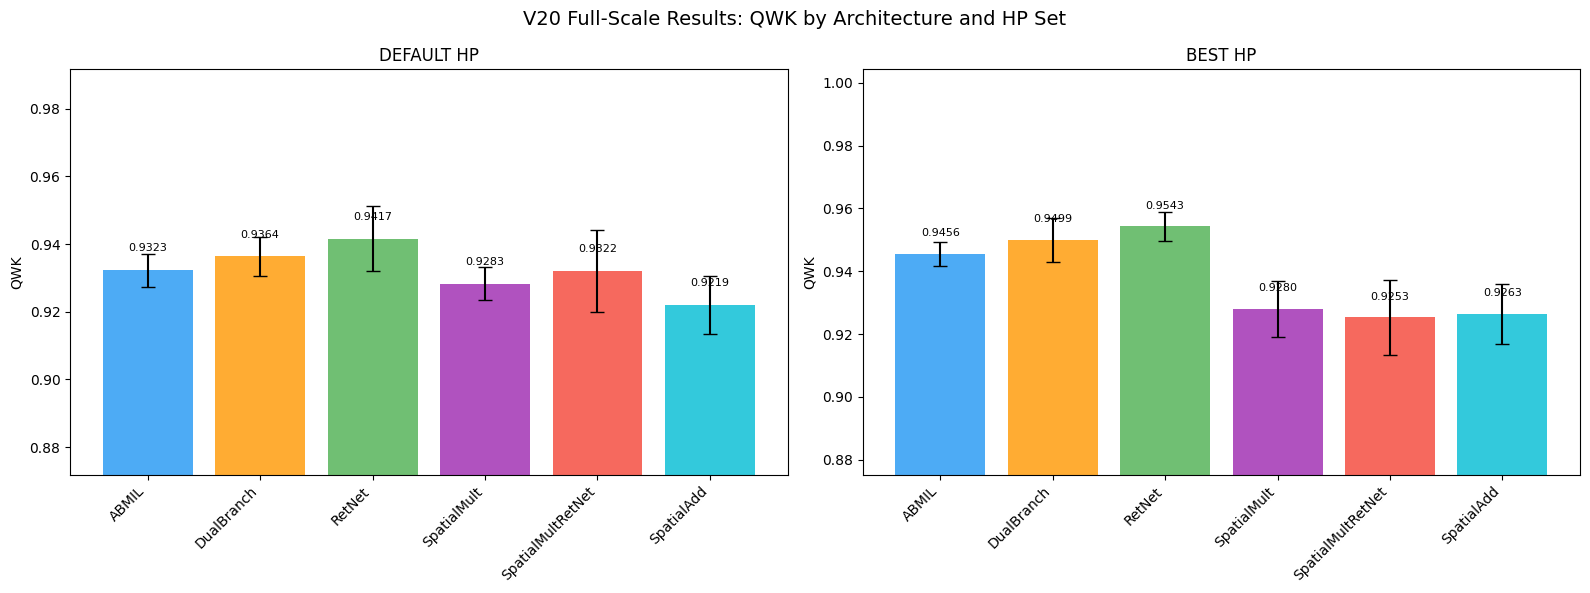

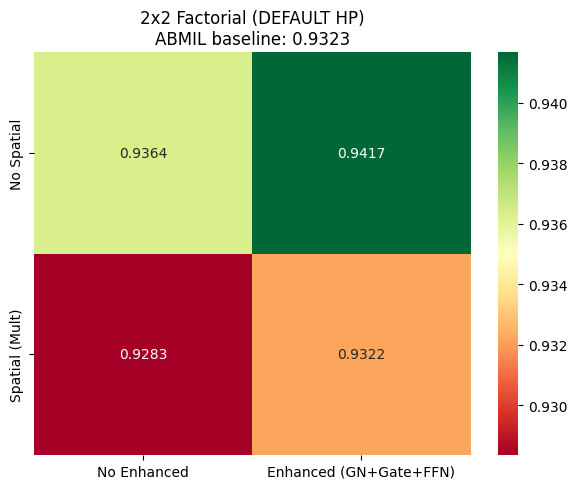

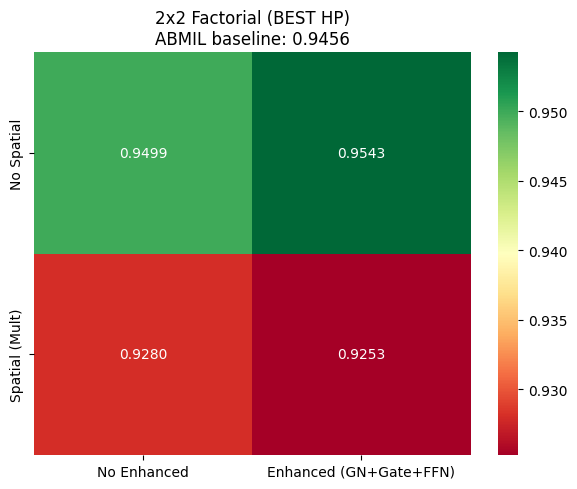

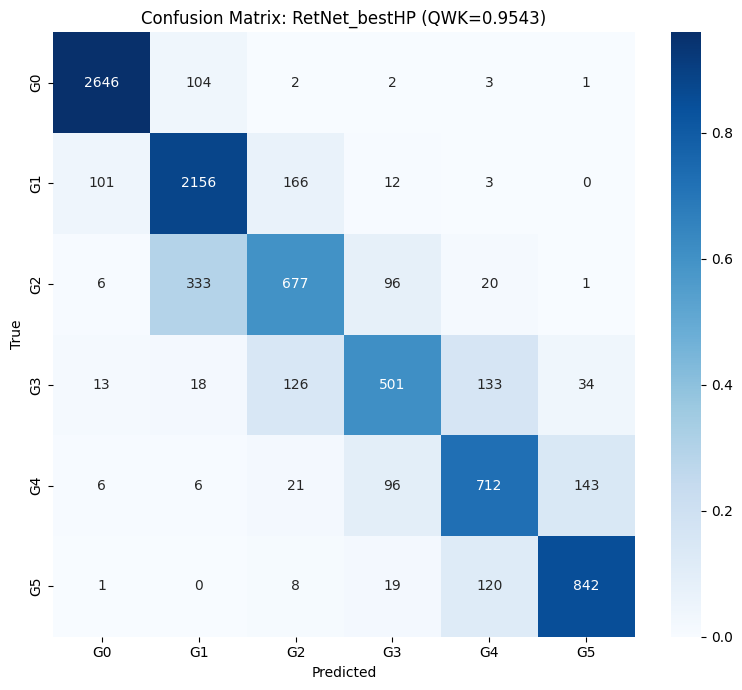

Plots saved to /content/drive/MyDrive/CLAM_TR_Results/v20_fullscale/UNI
Final summary saved to /content/drive/MyDrive/CLAM_TR_Results/v20_fullscale/UNI/v20_final_summary.json
Completed: 12/12 experiments

######################################################################
# PIPELINE COMPLETE
######################################################################
  UNI: COMPLETED


In [30]:
def run_all_encoders():
    """Run full pipeline for all active encoders.

    OPTIMIZED: Features preloaded into RAM then packed onto GPU (float16).
    Training runs with ZERO CPU->GPU transfers = maximum GPU utilization.
    Falls back to CPU cache if GPU too small (e.g. UNI2-h at 1536d).
    """
    import traceback

    # Phase 0 once
    set_encoder(ACTIVE_ENCODERS[0])
    df, cw = run_phase_0(device)

    encoder_results = {}

    for enc_idx, enc_name in enumerate(ACTIVE_ENCODERS):
        sep = '#' * 70
        print()
        print(sep)
        print(f"# ENCODER {enc_idx+1}/{len(ACTIVE_ENCODERS)}: {enc_name}")
        print(sep)
        print()

        try:
            set_encoder(enc_name)

            # UNI v1: extract features if needed
            if enc_name == 'UNI':
                uni_dir = ENCODERS['UNI']['features_dir']
                existing = len([f for f in os.listdir(uni_dir) if f.endswith('.pt')]) if os.path.isdir(uni_dir) else 0
                print(f"  UNI v1 features found: {existing}")
                if existing < 9000:
                    print(f"  Need to extract UNI v1 features ({existing} < 9000)")
                    slides_ok = verify_slide_reading(
                        slides_dir=EXTRACTION_CONFIG['slides_dir'],
                        slide_ext=EXTRACTION_CONFIG['slide_ext'],
                        n_samples=5
                    )
                    if not slides_ok:
                        raise RuntimeError("Slide reading validation failed.")
                    print("  Starting UNI v1 feature extraction...")
                    extract_uni_features()
                    existing = len([f for f in os.listdir(uni_dir) if f.endswith('.pt')])
                    print(f"  Extraction done: {existing} features")
                else:
                    print(f"  Features already extracted ({existing} files)")

            validate_encoder_features(enc_name)

            # ══════════════════════════════════════════════════════
            # STEP 1: Preload features into CPU RAM
            # ══════════════════════════════════════════════════════
            print()
            print("=" * 60)
            print("STEP 1: PRELOADING FEATURES INTO RAM")
            print("=" * 60)
            PANDADataset.preload_all(
                df['image_id'].tolist(),
                FEATURES_DIR,
                CONFIG['file_ext'],
                max_workers=8
            )

            # ══════════════════════════════════════════════════════
            # STEP 2: Pack features onto GPU (float16)
            # UNI (1024d): ~8.8GB → fits in 15GB GPU ✓
            # UNI2-h (1536d): ~15.3GB → auto-fallback to CPU
            # ══════════════════════════════════════════════════════
            print()
            print("=" * 60)
            print("STEP 2: TRANSFERRING FEATURES TO GPU")
            print("=" * 60)
            gpu_ok = PANDADataset.move_to_gpu(device)
            if gpu_ok:
                print("Training will run with ZERO CPU->GPU transfers!")
            else:
                print("Training will use per-slide CPU->GPU transfers (still fast from RAM)")
            print("=" * 60)
            print()

            lr_quick_test(df, cw, device)
            run_all_experiments(EXPERIMENTS, df, cw, device)

            encoder_results[enc_name] = 'COMPLETED'

            print()
            print(sep)
            print(f"# COMPLETED: {enc_name} ({enc_idx+1}/{len(ACTIVE_ENCODERS)})")
            print(sep)

        except Exception as e:
            print(f"\n  ENCODER FAILED: {enc_name}")
            print(f"  Error: {e}")
            traceback.print_exc()
            encoder_results[enc_name] = f'FAILED: {e}'
            torch.cuda.empty_cache()
            print(f"\n  Continuing to next encoder...\n")

        # Clear ALL caches between encoders (different dimensions!)
        if len(ACTIVE_ENCODERS) > 1:
            PANDADataset.clear_cache()

    # Per-encoder analysis
    for enc_name in ACTIVE_ENCODERS:
        if encoder_results.get(enc_name) != 'COMPLETED':
            continue
        set_encoder(enc_name)
        print()
        print('#' * 70)
        print(f"# ANALYSIS: {enc_name}")
        print('#' * 70)
        try:
            print_full_results()
            run_statistical_analysis()
            factorial_decomposition()
            detect_scenario()
            plot_results()
            save_final_summary()
        except Exception as e:
            print(f"  Analysis error for {enc_name}: {e}")

    # Summary
    print()
    print('#' * 70)
    print("# PIPELINE COMPLETE")
    print('#' * 70)
    for enc, status in encoder_results.items():
        print(f"  {enc}: {status}")

    completed = [e for e, s in encoder_results.items() if s == 'COMPLETED']
    if len(completed) > 1:
        print()
        compare_encoders()


# Auto-run
if AUTO_RUN:
    run_all_encoders()
